## Mcardiac perturbation

Edit input, checkpoint, and output paths in `perturb/config.yaml`. Review intervention settings below, then run from top to bottom.


In [63]:
from pathlib import Path
import os, sys, glob, json, inspect, copy
sys.dont_write_bytecode = True
EXPERIMENT_DIR = next(q for p in [Path.cwd(), *Path.cwd().parents] for q in [p, p/'Mcardiac', p/'experiments/Mcardiac'] if q.name == 'Mcardiac' and (q/'perturb/config.yaml').is_file())
PERTURB_DIR = EXPERIMENT_DIR / 'perturb'
sys.path.insert(0, str(EXPERIMENT_DIR.parents[1] / 'src'))
from stvirtual.perturb import prepare_runtime
prepare_runtime(EXPERIMENT_DIR)
import scanpy as sc
import torch
import numpy as np
import pandas as pd
import anndata as ad
import scvi
import scipy.sparse as sp
from scipy import sparse
import torch.nn.functional as F
import matplotlib.pyplot as plt
from stvirtual.perturb import PerturbationSession, read_frames, find_gene_name
session = PerturbationSession('Mcardiac', config_path=PERTURB_DIR/'config.yaml')
paths = session.paths


In [3]:
adata_roll = read_frames(session.baseline_paths())
adata_roll

sample
E9.5h_to_E11.5h_f0020_t1p0000    51671
E9.5h_to_E11.5h_f0019_t0p9500    51334
E9.5h_to_E11.5h_f0018_t0p9000    51016
E9.5h_to_E11.5h_f0017_t0p8500    50694
E9.5h_to_E11.5h_f0016_t0p8000    50364
E9.5h_to_E11.5h_f0015_t0p7500    50026
E9.5h_to_E11.5h_f0014_t0p7000    49682
E9.5h_to_E11.5h_f0013_t0p6500    49335
E9.5h_to_E11.5h_f0012_t0p6000    48987
E9.5h_to_E11.5h_f0011_t0p5500    48638
E9.5h_to_E11.5h_f0010_t0p5000    48287
E9.5h_to_E11.5h_f0009_t0p4500    47931
E9.5h_to_E11.5h_f0008_t0p4000    47571
E9.5h_to_E11.5h_f0007_t0p3500    47211
E9.5h_to_E11.5h_f0006_t0p3000    46849
E9.5h_to_E11.5h_f0005_t0p2500    46484
E9.5h_to_E11.5h_f0004_t0p2000    46117
E9.5h_to_E11.5h_f0003_t0p1500    45749
E9.5h_to_E11.5h_f0002_t0p1000    45381
E9.5h_to_E11.5h_f0001_t0p0500    45013
E9.5h_to_E11.5h_f0000_t0p0000    44644
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 1012984 × 21792
    obs: 'cx', 'cy', 'cz', 'layer_idx', 'layer_name', 'uid', 'parent_uid', 'is_birth', 'is_diff', 'diff_alpha', 'diff_tgt_layer', 'diff_tgt_layer_name', 'sample', 'frame', 'x_roll', 'y_roll'
    obsm: 'X_latent', 'spatial'

In [193]:
adata_roll.obs['t'] = adata_roll.obs['frame'].astype(int)

In [5]:
adata_roll.obs['layer_name'].value_counts()

layer_name
Ventricular cardiomyocytes                                305266
Atrial cardiomyocytes                                     160831
Cardiac fibroblasts                                       110565
Proepicardium                                              97303
Endocardial cells                                          73662
LV/atrioventricular canal/common atrium cardiomyocytes     63588
Primitive erythroid cells                                  56563
Outflow tract cardiomyocytes                               51041
Second heart field-derived cardiomyocytes                  35249
Cardiopharyngeal mesoderm                                  31443
Arterial endothelial cells                                 27473
Name: count, dtype: int64

In [ ]:
import re
import numpy as np
import pandas as pd

def classify_lv_origin_cell_state_transitions(
    adata,
    uid_col="uid",
    layer_col="layer_name",
    t_col="t",                 # If absent, try parsing time from sample.
    sample_col="sample",
    start_label="LV/atrioventricular canal/common atrium cardiomyocytes",
    atrial_label="Atrial cardiomyocytes",
    ventricular_label="Ventricular cardiomyocytes",
    start_t=None,              # Use the earliest time by default.
    verbose=True,
):
    obs = adata.obs.copy()

    def get_1d_col(df, col):
        x = df[col]
        if isinstance(x, pd.DataFrame):
            print(f"[warn] Duplicate columns named {col!r}; using the first column")
            x = x.iloc[:, 0]
        return x

    def norm_uid(x):
        if pd.isna(x):
            return None
        s = str(x).strip()
        if s in {"", "nan", "NaN", "None"}:
            return None
        try:
            xf = float(s)
            if np.isfinite(xf) and xf.is_integer():
                return str(int(xf))
        except Exception:
            pass
        return s

    def resolve_time(obs):
        if t_col in obs.columns:
            t = pd.to_numeric(get_1d_col(obs, t_col), errors="coerce")
            if t.notna().sum() > 0:
                return t, t_col

        if sample_col in obs.columns:
            s = get_1d_col(obs, sample_col).astype(str)

            # Common format: ..._f0012_... -> 12.
            t1 = s.str.extract(r"_f(\d+)_", expand=False)
            t1 = pd.to_numeric(t1, errors="coerce")
            if t1.notna().sum() > 0:
                return t1, f"{sample_col} parsed by _f(\\d+)_"

            # Fallback: extract the last integer from the string.
            t2 = s.str.extract(r"(\d+)(?!.*\d)", expand=False)
            t2 = pd.to_numeric(t2, errors="coerce")
            if t2.notna().sum() > 0:
                return t2, f"{sample_col} parsed by last integer"

        raise ValueError(
            f"No usable {t_col!r}; unable to parse time from {sample_col!r}."
        )

    time_vec, time_source = resolve_time(obs)

    df = pd.DataFrame({
        "uid": get_1d_col(obs, uid_col).map(norm_uid),
        "layer": get_1d_col(obs, layer_col).astype(str),
        "t": pd.to_numeric(time_vec, errors="coerce"),
    }).dropna(subset=["uid", "layer", "t"]).copy()

    if len(df) == 0:
        raise ValueError("No usable data remain after cleaning.")

    df["t"] = df["t"].astype(int)
    df = df.sort_values(["uid", "t"]).reset_index(drop=True)

    if start_t is None:
        start_t = int(df["t"].min())

    # Target source cells in the starting frame.
    start_df = df.loc[
        (df["t"] == start_t) &
        (df["layer"] == start_label),
        ["uid", "layer", "t"]
    ].copy()

    start_uids = set(start_df["uid"].tolist())

    if len(start_uids) == 0:
        raise ValueError(
            f"At start time t={start_t}, no cells have layer_name == {start_label!r}."
        )

    traj = df[df["uid"].isin(start_uids)].copy()

    rows = []
    for uid, sub in traj.groupby("uid", sort=False):
        sub = sub.sort_values("t").copy()

        layers_all = sub["layer"].tolist()
        layers_future = sub.loc[sub["t"] > start_t, "layer"].tolist()

        has_atrial = atrial_label in layers_future
        has_ventricular = ventricular_label in layers_future

        if has_atrial and not has_ventricular:
            cell_state_transition = "future_atrial"
        elif has_ventricular and not has_atrial:
            cell_state_transition = "future_ventricular"
        elif has_atrial and has_ventricular:
            cell_state_transition = "both"
        else:
            cell_state_transition = "neither"

        first_atrial_t = sub.loc[sub["layer"] == atrial_label, "t"]
        first_vent_t = sub.loc[sub["layer"] == ventricular_label, "t"]

        rows.append({
            "uid": uid,
            "start_t": start_t,
            "start_layer": start_label,
            "cell_state_transition_class": cell_state_transition,
            "ever_atrial": has_atrial,
            "ever_ventricular": has_ventricular,
            "first_atrial_t": int(first_atrial_t.iloc[0]) if len(first_atrial_t) > 0 else np.nan,
            "first_ventricular_t": int(first_vent_t.iloc[0]) if len(first_vent_t) > 0 else np.nan,
            "n_timepoints": len(sub),
            "trajectory_layers": " -> ".join(sub["layer"].tolist()),
        })

    result_df = pd.DataFrame(rows).sort_values(
        ["cell_state_transition_class", "uid"]
    ).reset_index(drop=True)

    uid_dict = {
        "future_atrial": result_df.loc[result_df["cell_state_transition_class"] == "future_atrial", "uid"].tolist(),
        "future_ventricular": result_df.loc[result_df["cell_state_transition_class"] == "future_ventricular", "uid"].tolist(),
        "both": result_df.loc[result_df["cell_state_transition_class"] == "both", "uid"].tolist(),
        "neither": result_df.loc[result_df["cell_state_transition_class"] == "neither", "uid"].tolist(),
    }

    if verbose:
        print(f"[time source] {time_source}")
        print(f"[start_t] {start_t}")
        print(f"[start LV-origin cells] {len(start_uids)}")
        print(result_df["cell_state_transition_class"].value_counts(dropna=False).sort_index())

    return result_df, uid_dict, traj

In [7]:
result_df, uid_dict, traj_df = classify_lv_origin_cell_state_transitions(
    adata_roll,
    uid_col="uid",
    layer_col="layer_name",
    t_col="t",          # If t is absent, try parsing time from sample.
    sample_col="sample",
    start_label="LV/atrioventricular canal/common atrium cardiomyocytes",
    atrial_label="Atrial cardiomyocytes",
    ventricular_label="Ventricular cardiomyocytes",
    start_t=None,       # Use the earliest time automatically.
    verbose=True,
)

[time source] t
[start_t] 0
[start LV-origin cells] 11505
cell_state_transition_class
future_atrial         4460
future_ventricular    4633
neither               2412
Name: count, dtype: int64


In [8]:
print(result_df.head())
print("future_atrial n =", len(uid_dict["future_atrial"]))
print("future_ventricular n =", len(uid_dict["future_ventricular"]))
print("both n =", len(uid_dict["both"]))
print("neither n =", len(uid_dict["neither"]))

     uid  start_t                                        start_layer  \
0  10007        0  LV/atrioventricular canal/common atrium cardio...   
1  10019        0  LV/atrioventricular canal/common atrium cardio...   
2  10020        0  LV/atrioventricular canal/common atrium cardio...   
3  10025        0  LV/atrioventricular canal/common atrium cardio...   
4  10028        0  LV/atrioventricular canal/common atrium cardio...   

      cell_state_transition_class  ever_atrial  ever_ventricular  first_atrial_t  \
0  future_atrial         True             False             5.0   
1  future_atrial         True             False             5.0   
2  future_atrial         True             False             2.0   
3  future_atrial         True             False             3.0   
4  future_atrial         True             False             2.0   

   first_ventricular_t  n_timepoints  \
0                  NaN            16   
1                  NaN            15   
2                  NaN     

In [11]:
adata_ori = session.input()
adata_ori

AnnData object with n_obs × n_vars = 96315 × 21792
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region', 'sample', 'stage', 'transf_anno', 'ManualAnnotation', 'slice_id', 'embryo_id', 'dataset', 'cx_aligned', 'cy_aligned', 'cz_aligned', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'mapped_celltype_colors', 'neighbors', 'pca', 'stage_colors', 'umap'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial_3d', 'spatial_3d_stage_norm'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [23]:
adata_95 = adata_ori[adata_ori.obs['stage']=='E9.5h']
adata_115 = adata_ori[adata_ori.obs['stage']=='E11.5h']
print(adata_115)
print(adata_95)

View of AnnData object with n_obs × n_vars = 51671 × 21792
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region', 'sample', 'stage', 'transf_anno', 'ManualAnnotation', 'slice_id', 'embryo_id', 'dataset', 'cx_aligned', 'cy_aligned', 'cz_aligned', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'mapped_celltype_colors', 'neighbors', 'pca', 'stage_colors', 'umap'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial_3d', 'spatial_3d_stage_norm'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
View of AnnData object with n_obs × n_vars = 44644 × 21792
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region', 'sample', 'stage', 'transf_anno', 'ManualAnnotation', 'slice_id', 'embryo_i

In [14]:
adata01 = sc.read_h5ad(session.baseline_paths()[0])
adata01

Only considering the two last: ['.5h_f0000_t0p0000', '.h5ad'].
Only considering the two last: ['.5h_f0000_t0p0000', '.h5ad'].


AnnData object with n_obs × n_vars = 44644 × 21792
    obs: 'cx', 'cy', 'cz', 'layer_idx', 'layer_name', 'uid', 'parent_uid', 'is_birth', 'is_diff', 'diff_alpha', 'diff_tgt_layer', 'diff_tgt_layer_name', 'sample', 'frame', 'x_roll', 'y_roll'
    uns: 'sample'
    obsm: 'X_latent', 'spatial'

In [35]:
from stvirtual.perturb import baseline_cell_state_transitions
adata_95, verified_cell_state_transitions = baseline_cell_state_transitions(adata_95,session.config['baseline_frames'],paths['stage1'],
    celltype_key='mapped_celltype',start_label=session.config['start_label'])
uid_dict = {group: np.array([uid for uid,cell_state_transition in verified_cell_state_transitions.items() if cell_state_transition==group])
            for group in ['future_atrial','future_ventricular','both','neither']}
print({k:len(v) for k,v in uid_dict.items()})


In [29]:
import numpy as np
import pandas as pd
from scipy import sparse

# ========= 1) LR pairs to plot.
VENTRICULAR_PAIRS = [
    "Cdh2|Cdh2",
    "Hspg2|Dag1",
    "Lama4|Dag1",
    "Lamc1|Dag1",
    "Lamb1|Dag1",
    "Wnt5a|Mcam",
    "Tnfsf12|Tnfrsf12a",
    "Lama2|Dag1",
    "Flg|Pard3",
    "Cd200|Cd200r4",
    "Igf2|Igf1r",
    "Agrn|Dag1",
    "Nrg4|Erbb4",
    "Hbegf|Erbb4",
    "F2|Pard3",   # LR pair.
]

ATRIAL_PAIRS = [
    "Wnt11|Fzd1",
    "Negr1|Negr1",
    "Pdgfc|Pdgfra",
    "Pomc|Oprl1",
    "Lama2|Sv2a",
    "Hbegf|Egfr",
    "Nrxn3|Nlgn1",
    "Gas6|Axl",
    "Mif|Ackr3",
    "Nrg2|Erbb3",
    "Penk|Oprl1",
    "Wnt5b|Fzd1",
    "Wnt5a|Fzd1",
    "Egf|Egfr",
    "Ncam1|L1cam",
]

## Modify LR expression and infer the representation

Apply expression changes and infer `X_scanvi_pert` with the saved scanVI model.


In [30]:
# Cell_state_transition-dependent LR expression scaling is implemented by the shared perturbation session.


In [37]:
adata_query, info = session.apply_intervention(adata_ori)
adata_95_perturbed = adata_query[
    adata_query.obs[session.config["sample_key"]].astype(str).eq(session.config["source"])].copy()
adata_95_perturbed.layers["counts_cell_state_transition_perturbed"] = adata_95_perturbed.layers["counts"].copy()
info


[done] output layer = counts_cell_state_transition_perturbed
[future_ventricular cells] = 4633
[future_atrial cells]      = 4460
[vent genes total/found]   = 22 / 22
[atrial genes total/found] = 25 / 25
[shared genes] = ['Hbegf', 'Lama2', 'Wnt5a']


In [38]:
adata_95_perturbed

AnnData object with n_obs × n_vars = 44644 × 21792
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region', 'sample', 'stage', 'transf_anno', 'ManualAnnotation', 'slice_id', 'embryo_id', 'dataset', 'cx_aligned', 'cy_aligned', 'cz_aligned', '_scvi_batch', '_scvi_labels', 'uid', 'cell_state_transition_class'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'mapped_celltype_colors', 'neighbors', 'pca', 'stage_colors', 'umap'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial_3d', 'spatial_3d_stage_norm'
    varm: 'PCs'
    layers: 'counts', 'counts_cell_state_transition_perturbed'
    obsp: 'connectivities', 'distances'

In [39]:
adata_115

View of AnnData object with n_obs × n_vars = 51671 × 21792
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region', 'sample', 'stage', 'transf_anno', 'ManualAnnotation', 'slice_id', 'embryo_id', 'dataset', 'cx_aligned', 'cy_aligned', 'cz_aligned', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'mapped_celltype_colors', 'neighbors', 'pca', 'stage_colors', 'umap'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial_3d', 'spatial_3d_stage_norm'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [40]:
model_dir = paths['scanvi']
model = session.scanvi()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /home/zhouyj/stVirtual_revision/R2/C9/results/checkpoints/heart_9_11_ckpt/scvi/scanvi/model.pt already downloaded                     


In [41]:
# The shared session assembles source and target counts before representation inference.


In [42]:
adata_query = session.reinfer(adata_query, model=model)


Anndata setup with scvi-tools version 1.4.0.

Setup via `SCANVI.setup_anndata` with arguments:

{
│   'labels_key': 'mapped_celltype',
│   'unlabeled_category': 'Unknown',
│   'layer': 'counts',
│   'batch_key': 'stage',
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None,
│   'use_minified': True
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   2   │
│         n_cells          │ 96315 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  12   │
│          n_vars          │ 21792 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │  adata.layers['counts']   │
│    batch     │ adata.obs['_scvi_batch']  │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                  batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['stage'] │   E9.5h    │          0          │
│                    │   E11.5h   │          1          │
└────────────────────┴────────────┴─────────────────────┘

                                             labels State Registry                                             
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃       Source Location        ┃                       Categories                       ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['mapped_celltype'] │               Arterial endothelial cells               │          0          │
│                              │                 Atrial cardiomyocytes                  │          1          │
│                              │                  Cardiac fibroblasts                   │          2          │
│                              │               Cardiopharyngeal mesoderm                │          3          │
│                              │                   Endocardial cells                    │          4          │
│                              │ LV/atrioventricular canal/common atrium cardiomyocytes │          5          │
│                              │              Outflow tract cardiomyocytes              │          6          │
│                              │               Primitive erythroid cells                │          7          │
│                              │                     Proepicardium                      │          8          │
│                              │       Second heart field-derived cardiomyocytes        │          9          │
│                              │               Ventricular cardiomyocytes               │         10          │
│                              │                        Unknown                         │         11          │
└──────────────────────────────┴────────────────────────────────────────────────────────┴─────────────────────┘

X:
  attr_key: counts
  attr_name: layers
batch:
  attr_key: _scvi_batch
  attr_name: obs
labels:
  attr_key: _scvi_labels
  attr_name: obs

INFO     Found 100.0% reference vars in query data.                                                                
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [ ]:
adata_query_95 = adata_query[
    adata_query.obs[session.config["sample_key"]].astype(str).eq(session.config["source"])].copy()
adata_query_115 = adata_query[
    adata_query.obs[session.config["sample_key"]].astype(str).eq(session.config["target"])].copy()


In [49]:
adata_query_115

AnnData object with n_obs × n_vars = 51671 × 21792
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region', 'sample', 'stage', 'transf_anno', 'ManualAnnotation', 'slice_id', 'embryo_id', 'dataset', 'cx_aligned', 'cy_aligned', 'cz_aligned', '_scvi_batch', '_scvi_labels', '_query_src'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial_3d', 'spatial_3d_stage_norm', 'X_scanvi_pert'
    varm: 'PCs'
    layers: 'counts'

In [48]:
adata_query_95

AnnData object with n_obs × n_vars = 44644 × 21792
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region', 'sample', 'stage', 'transf_anno', 'ManualAnnotation', 'slice_id', 'embryo_id', 'dataset', 'cx_aligned', 'cy_aligned', 'cz_aligned', '_scvi_batch', '_scvi_labels', '_query_src'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial_3d', 'spatial_3d_stage_norm', 'X_scanvi_pert'
    varm: 'PCs'
    layers: 'counts'

## Stage 1 and Stage 2 simulation

Run volumetric transport and transition inference with the perturbed input.


In [47]:
# Stage-1 inference uses the current public model and checkpoint schema.
transport = session.transport

In [51]:
res1_zs = session.transport(adata_query_95, adata_query_115)

[ctx] scale 1/1: sparse matmul ...  (E=714304)
[ctx] scale 1/1: sparse matmul ...  (E=826736)
[Guide3D] sinkhorn_unbalanced eps 0.0100 -> 0.0320 (retries=22)


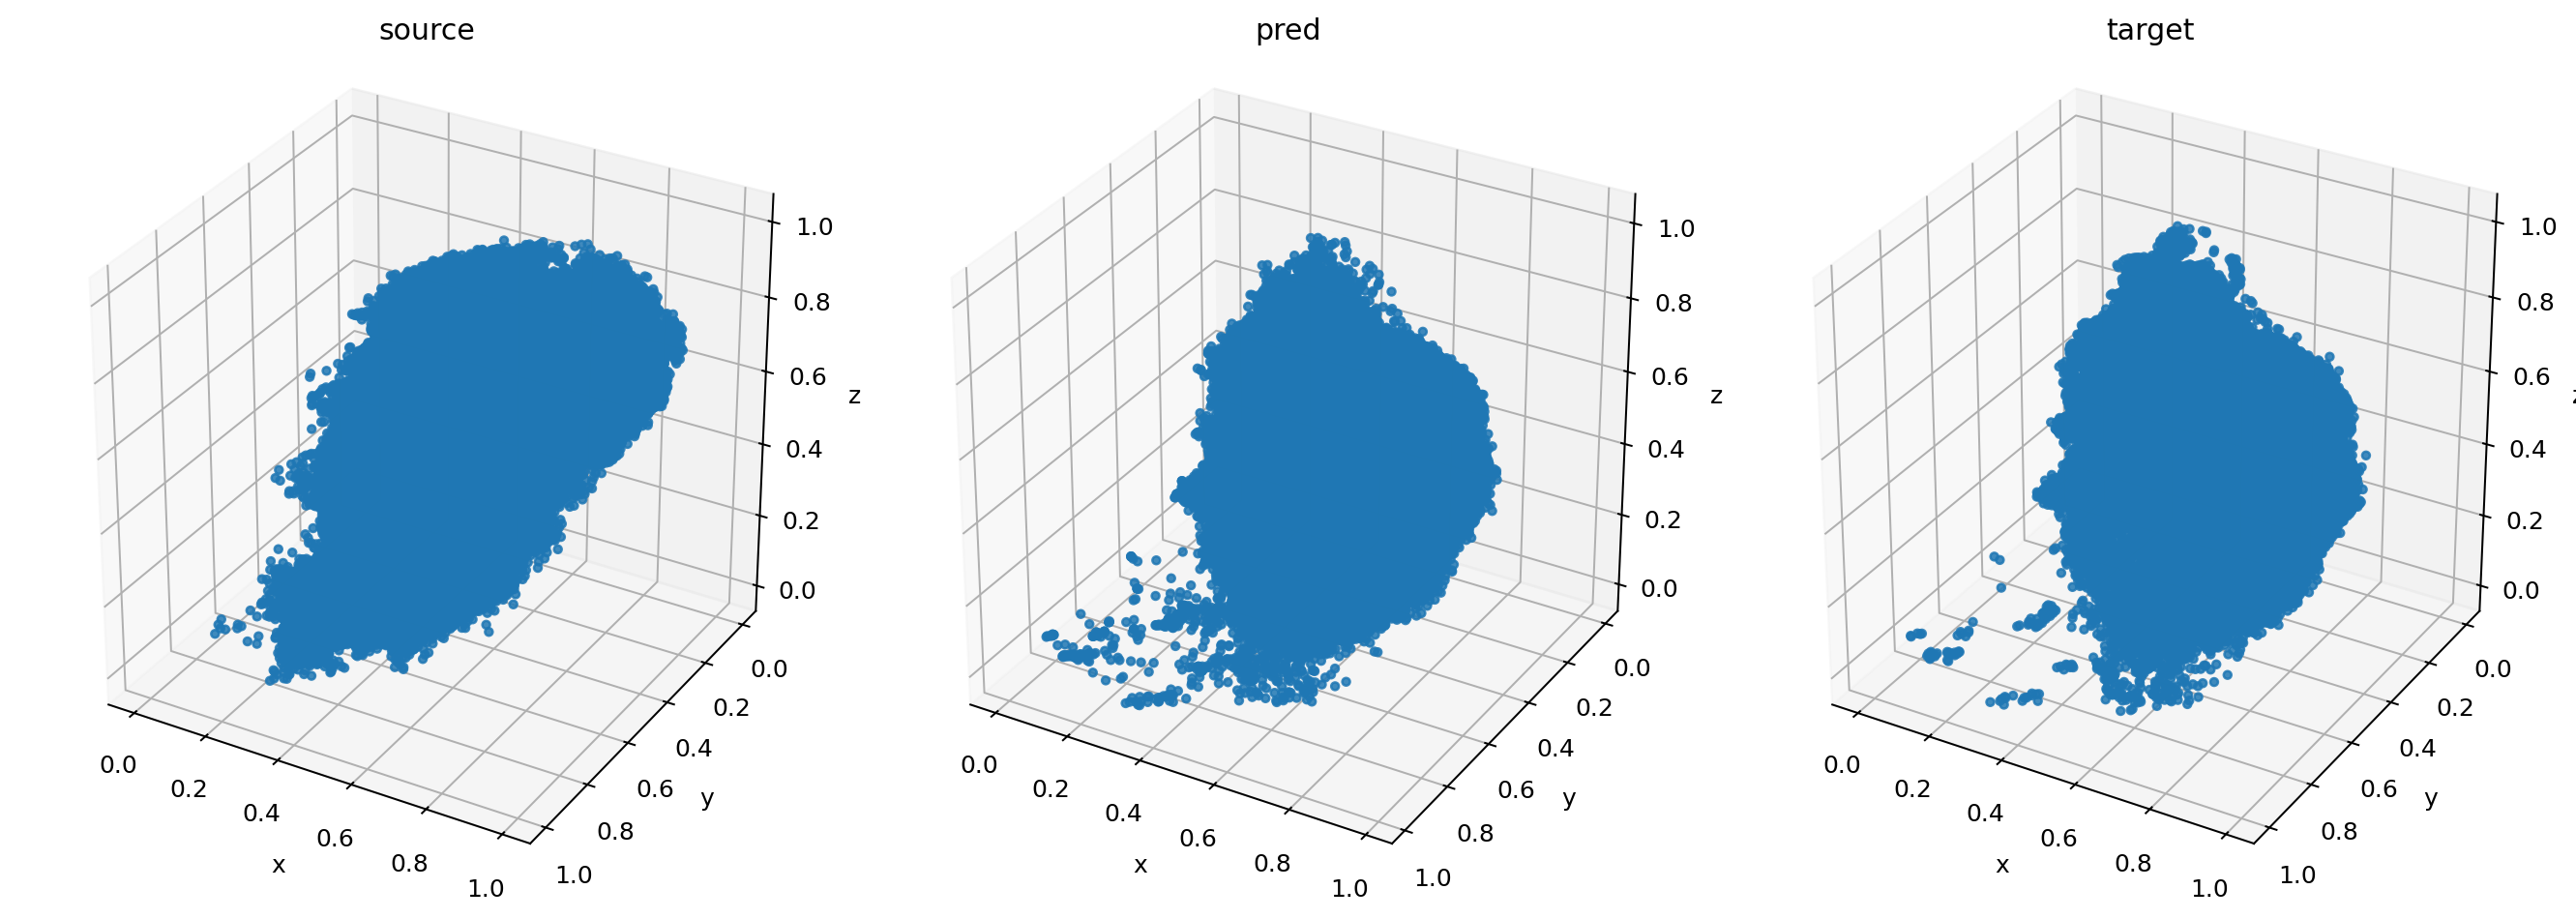

In [52]:
import numpy as np
import matplotlib.pyplot as plt

X0 = res1_zs["coords0"].detach().cpu().numpy()
X1 = res1_zs["x1"].detach().cpu().numpy()
XT = res1_zs["coords_tgt"].detach().cpu().numpy()

# Use the first three coordinate dimensions when more are available.
X0 = X0[:, :3]
X1 = X1[:, :3]
XT = XT[:, :3]

fig = plt.figure(figsize=(15, 5), dpi=180)

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax3 = fig.add_subplot(1, 3, 3, projection="3d")

ax1.scatter(X0[:, 0], X0[:, 1], X0[:, 2], s=10, alpha=0.85)
ax1.set_title("source")

ax2.scatter(X1[:, 0], X1[:, 1], X1[:, 2], s=10, alpha=0.85)
ax2.set_title("pred")

ax3.scatter(XT[:, 0], XT[:, 1], XT[:, 2], s=10, alpha=0.85)
ax3.set_title("target")

for ax in [ax1, ax2, ax3]:
    ax.set_box_aspect([1, 1, 1])   
    ax.invert_yaxis()              
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

plt.tight_layout()
plt.show()

In [55]:
# Stage-2 inference is handled by session.transition using the public interface.

In [56]:
# Policy architecture is loaded by the current public transition model.

In [57]:
# Inference uses session.transition; no research model imports are required.

In [59]:
session.save_input(adata_query, session.start() / "adata_query.h5ad")


In [60]:
adata_query

AnnData object with n_obs × n_vars = 96315 × 21792
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region', 'sample', 'stage', 'transf_anno', 'ManualAnnotation', 'slice_id', 'embryo_id', 'dataset', 'cx_aligned', 'cy_aligned', 'cz_aligned', '_scvi_batch', '_scvi_labels', '_query_src'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial_3d', 'spatial_3d_stage_norm', 'X_scanvi_pert'
    varm: 'PCs'
    layers: 'counts'

In [64]:
device = torch.device(session.device)
ctx, pack_lower, res2_zs = session.transition(adata_query, res1_zs)
state_final = res2_zs['state_final']
coords_gen = state_final['coords']
layers_gen = state_final['layers']
latent_gen = state_final['latent']
alpha_gen = state_final['diff_alpha']

# Match baseline identities to this simulation's validated source row order.
uid_dict = {group: np.array([session.baseline_to_simulation_uid[str(uid)] for uid in ids]) for group,ids in uid_dict.items()}


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /home/zhouyj/stVirtual_revision/R2/C9/results/checkpoints/heart_9_11_ckpt/scvi/scanvi/model.pt already downloaded                     
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
[auto cap 3D] 2 {'src': {'q': 0.9, 'quantile_value': 2.0, 'mean': 1.1451584100723267, 'max': 4.0, 'n_cells_used': 38985}, 'tgt': {'q': 0.9, 'quantile_value': 2.0, 'mean': 1.3460885286331177, 'max': 6.0, 'n_cells_used': 38233}, 'cap0': 2, 'capT': 2, 'cap': 2}


In [67]:
import numpy as np
import pandas as pd
import torch
import anndata as ad
import scipy.sparse as sp


def _to_np(x):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _get_spatial_norm_stats_from_ctx(ctx, spatial_dim):
    """
    Prefer the 3D xyz_mu / xyz_s values;
    Otherwise, fall back to the 2D xy_mu / xy_s values.
    Supports:
      mu: (1, spatial_dim)
      s : (1, spatial_dim), (1,1), or a scalar
    """
    if ctx is None:
        return None, None

    mu = None
    ss = None

    if hasattr(ctx, "xyz_mu") and hasattr(ctx, "xyz_s"):
        mu = _to_np(ctx.xyz_mu).astype(np.float32).reshape(1, -1)
        ss = _to_np(ctx.xyz_s).astype(np.float32)
    elif hasattr(ctx, "xy_mu") and hasattr(ctx, "xy_s"):
        mu = _to_np(ctx.xy_mu).astype(np.float32).reshape(1, -1)
        ss = _to_np(ctx.xy_s).astype(np.float32)
    else:
        return None, None

    # Normalize the shape of ss.
    if np.ndim(ss) == 0:
        ss = np.array([[float(ss)]], dtype=np.float32)
    else:
        ss = np.asarray(ss, dtype=np.float32).reshape(1, -1)

    if mu.shape[1] < spatial_dim:
        raise ValueError(
            f"Insufficient spatial mean dimensions in ctx: need {spatial_dim}, got mu={mu.shape}"
        )

    # Broadcast a scalar s across spatial dimensions.
    if ss.shape[1] == 1 and spatial_dim > 1:
        ss = np.repeat(ss, spatial_dim, axis=1)

    if ss.shape[1] < spatial_dim:
        raise ValueError(
            f"Insufficient spatial scale dimensions in ctx: need {spatial_dim}, got s={ss.shape}"
        )

    return mu[:, :spatial_dim], ss[:, :spatial_dim]


def build_history_adata_from_res2_3d(res2_zs, ctx=None, include_latent=True):
    states = res2_zs["history"]["state"]
    if len(states) == 0:
        raise ValueError("res2_zs['history']['state'] is empty")

    idx_to_layer = None
    if ctx is not None and hasattr(ctx, "layers_list") and ctx.layers_list is not None:
        idx_to_layer = {i: str(x) for i, x in enumerate(ctx.layers_list)}

    obs_list = []
    latent_list = []
    spatial_norm_list = []
    spatial_list = []

    first_coords = _to_np(states[0]["coords"]).astype(np.float32)
    if first_coords.ndim != 2:
        raise ValueError(f"state['coords'] must be a two-dimensional array; got {first_coords.shape}")
    spatial_dim = int(first_coords.shape[1])
    if spatial_dim not in (2, 3):
        raise ValueError(f"Only 2D/3D coordinates are supported; spatial_dim={spatial_dim}")

    mu, ss = _get_spatial_norm_stats_from_ctx(ctx, spatial_dim)

    for t, st in enumerate(states):
        coords = _to_np(st["coords"]).astype(np.float32)
        if coords.shape[1] != spatial_dim:
            raise ValueError(
                f"Frame {t} coordinate dimensions do not match: expected {spatial_dim}, got {coords.shape}"
            )

        n = coords.shape[0]

        layers = _to_np(st.get("layers", np.full(n, -1))).astype(np.int64)
        uid = _to_np(st.get("uid", np.arange(n))).astype(np.int64)
        parent_uid = _to_np(st.get("parent_uid", np.full(n, -1))).astype(np.int64)
        born_step = _to_np(st.get("born_step", np.full(n, -1))).astype(np.int32)

        is_diff = _to_np(st.get("is_diff", np.zeros(n, dtype=bool))).astype(bool)
        diff_alpha = _to_np(st.get("diff_alpha", np.zeros(n, dtype=np.float32))).astype(np.float32)

        # Support versions with and without diff_mid.
        diff_mid_raw = st.get("diff_mid", None)
        if diff_mid_raw is None:
            diff_mid = np.zeros(n, dtype=np.float32)
        else:
            diff_mid = _to_np(diff_mid_raw).astype(np.float32)

        diff_tgt_layer = _to_np(st.get("diff_tgt_layer", np.full(n, -1))).astype(np.int64)
        diff_enter_step = _to_np(st.get("diff_enter_step", np.full(n, -1))).astype(np.int32)
        commit_step = _to_np(st.get("commit_step", np.full(n, -1))).astype(np.int32)

        lr = _to_np(st.get("lr", np.full(n, np.nan))).astype(np.float32)
        anchor = _to_np(st.get("anchor", np.full(n, -1))).astype(np.int64)

        if idx_to_layer is not None:
            layer_name = np.array([idx_to_layer.get(int(i), str(i)) for i in layers], dtype=object)
            diff_tgt_layer_name = np.array(
                [idx_to_layer.get(int(i), str(i)) if int(i) >= 0 else "none" for i in diff_tgt_layer],
                dtype=object,
            )
        else:
            layer_name = layers.astype(str)
            diff_tgt_layer_name = np.where(diff_tgt_layer >= 0, diff_tgt_layer.astype(str), "none")

        late_prob = np.clip(diff_alpha - 0.5 * diff_mid, 0.0, 1.0).astype(np.float32)

        obs_dict = {
            "frame": t,
            "uid": uid,
            "parent_uid": parent_uid,
            "born_step": born_step,
            "anchor": anchor,
            "layer_idx": layers,
            "layer_name": layer_name,
            "is_diff": is_diff,
            "diff_alpha": diff_alpha,
            "diff_mid": diff_mid,
            "late_prob": late_prob,
            "diff_tgt_layer_idx": diff_tgt_layer,
            "diff_tgt_layer_name": diff_tgt_layer_name,
            "diff_enter_step": diff_enter_step,
            "commit_step": commit_step,
            "lr": lr,
        }

        # Store coordinates in obs for filtering and plotting.
        obs_dict["x_norm"] = coords[:, 0]
        obs_dict["y_norm"] = coords[:, 1]
        if spatial_dim == 3:
            obs_dict["z_norm"] = coords[:, 2]

        if mu is not None and ss is not None:
            coords_raw = (coords * ss + mu).astype(np.float32)
            obs_dict["x"] = coords_raw[:, 0]
            obs_dict["y"] = coords_raw[:, 1]
            if spatial_dim == 3:
                obs_dict["z"] = coords_raw[:, 2]
            spatial_list.append(coords_raw)

        obs = pd.DataFrame(
            obs_dict,
            index=[f"f{t:03d}_uid{int(u)}" for u in uid],
        )

        obs_list.append(obs)
        spatial_norm_list.append(coords)

        latent = st.get("latent", None)
        if include_latent and latent is not None:
            latent_list.append(_to_np(latent).astype(np.float32))

    obs_all = pd.concat(obs_list, axis=0)
    n_obs = obs_all.shape[0]

    # .X is an empty matrix.
    X_empty = sp.csr_matrix((n_obs, 0), dtype=np.float32)
    var_empty = pd.DataFrame(index=[])

    adata_hist = ad.AnnData(X=X_empty, obs=obs_all, var=var_empty)
    adata_hist.obsm["spatial_norm"] = np.concatenate(spatial_norm_list, axis=0).astype(np.float32)

    if len(spatial_list) == len(spatial_norm_list):
        adata_hist.obsm["spatial"] = np.concatenate(spatial_list, axis=0).astype(np.float32)

    if include_latent and len(latent_list) > 0:
        adata_hist.obsm["X_latent"] = np.concatenate(latent_list, axis=0).astype(np.float32)

    return adata_hist

In [68]:
adata_hist = build_history_adata_from_res2_3d(res2_zs, ctx=ctx, include_latent=True)

In [69]:
adata_hist

AnnData object with n_obs × n_vars = 1011924 × 0
    obs: 'frame', 'uid', 'parent_uid', 'born_step', 'anchor', 'layer_idx', 'layer_name', 'is_diff', 'diff_alpha', 'diff_mid', 'late_prob', 'diff_tgt_layer_idx', 'diff_tgt_layer_name', 'diff_enter_step', 'commit_step', 'lr', 'x_norm', 'y_norm', 'z_norm', 'x', 'y', 'z'
    obsm: 'spatial_norm', 'spatial', 'X_latent'

In [79]:
adata_hist.obs['frame'].value_counts()

frame
20    51671
19    51286
18    50937
17    50611
16    50295
15    49976
14    49647
13    49301
12    48940
11    48569
10    48198
9     47839
8     47488
7     47136
6     46786
5     46435
4     46081
3     45722
2     45360
1     45002
0     44644
Name: count, dtype: int64

In [71]:
uid_dict.keys()

dict_keys(['future_atrial', 'future_ventricular', 'both', 'neither'])

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def norm_uid(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s in {"", "nan", "NaN", "None"}:
        return None
    try:
        xf = float(s)
        if np.isfinite(xf) and xf.is_integer():
            return str(int(xf))
    except Exception:
        pass
    return s


def propagate_root_seed_from_frame0(adata_hist, seed_uids):
    """
    Propagate seed_uids forward from frame 0:
    - For a seed uid, root_seed = uid.
    - A newly born uid inherits root_seed from parent_uid when available.
    """
    obs = adata_hist.obs.copy()

    need_cols = ["uid", "parent_uid", "frame"]
    miss = [c for c in need_cols if c not in obs.columns]
    if len(miss) > 0:
        raise KeyError(f"adata_hist.obs is missing columns: {miss}")

    obs["uid_norm"] = obs["uid"].map(norm_uid)
    obs["parent_uid_norm"] = obs["parent_uid"].map(norm_uid)
    obs["frame"] = pd.to_numeric(obs["frame"], errors="coerce").astype(int)

    seed_uids = set(map(norm_uid, seed_uids))

    # First appearance of each uid (birth time).
    birth_df = (
        obs[["uid_norm", "parent_uid_norm", "frame"]]
        .dropna(subset=["uid_norm"])
        .sort_values(["frame", "uid_norm"])
        .drop_duplicates(subset=["uid_norm"], keep="first")
        .copy()
    )

    # Keep seeds that actually occur in frame 0.
    frame0_uids = set(
        obs.loc[obs["frame"] == obs["frame"].min(), "uid_norm"]
        .dropna()
        .astype(str)
        .tolist()
    )
    seed_uids = set(u for u in seed_uids if u in frame0_uids)

    root_seed_of = {}

    for _, row in birth_df.iterrows():
        uid = row["uid_norm"]
        parent = row["parent_uid_norm"]

        if uid in seed_uids:
            root_seed_of[uid] = uid
        elif parent in root_seed_of:
            root_seed_of[uid] = root_seed_of[parent]

    obs["root_seed"] = obs["uid_norm"].map(lambda x: root_seed_of.get(x, None))
    return obs, root_seed_of


def classify_terminal_cell_state_transition_per_seed(
    adata_hist,
    uid_dict,
    layer_col="layer_name",
    atrial_label="Atrial cardiomyocytes",
    ventricular_label="Ventricular cardiomyocytes",
):
    """
    Start with the future_atrial / future_ventricular uid groups in frame 0,
    Trace forward to the final frame and check for atrial / ventricular descendants of each starting uid.

    Returns:
    1) result_df: one row per starting uid
    2) conf_full: 2x4 matrix (atrial / ventricular / both / neither)
    3) conf_2x2: 2x2 matrix restricted to pure atrial / pure ventricular
    """
    obs = adata_hist.obs.copy()
    if layer_col not in obs.columns:
        raise KeyError(f"adata_hist.obs is missing {layer_col}")
    if "frame" not in obs.columns:
        raise KeyError("adata_hist.obs is missing frame")

    future_atrial = set(map(norm_uid, uid_dict.get("future_atrial", [])))
    future_ventricular = set(map(norm_uid, uid_dict.get("future_ventricular", [])))
    seed_uids = future_atrial | future_ventricular

    obs2, root_seed_of = propagate_root_seed_from_frame0(adata_hist, seed_uids)

    # source group
    def map_source_group(root_seed):
        if root_seed in future_atrial:
            return "future_atrial"
        if root_seed in future_ventricular:
            return "future_ventricular"
        return "other"

    obs2["source_group"] = obs2["root_seed"].map(map_source_group)

    final_frame = int(obs2["frame"].max())
    final_obs = obs2.loc[obs2["frame"] == final_frame].copy()
    final_obs = final_obs.loc[final_obs["root_seed"].notna()].copy()

    # Determine descendant types for each root_seed in the final frame.
    keep_roots = sorted(seed_uids)
    rows = []
    for root in keep_roots:
        sub = final_obs.loc[final_obs["root_seed"] == root].copy()
        layers = sub[layer_col].astype(str) if len(sub) > 0 else pd.Series([], dtype=str)

        has_a = bool((layers == atrial_label).any())
        has_v = bool((layers == ventricular_label).any())

        if has_a and not has_v:
            final_cell_state_transition = "atrial"
        elif has_v and not has_a:
            final_cell_state_transition = "ventricular"
        elif has_a and has_v:
            final_cell_state_transition = "both"
        else:
            final_cell_state_transition = "neither"

        rows.append({
            "root_seed": root,
            "source_group": (
                "future_atrial" if root in future_atrial
                else "future_ventricular" if root in future_ventricular
                else "other"
            ),
            "n_final_descendants": int(len(sub)),
            "n_atrial_final": int((layers == atrial_label).sum()) if len(sub) > 0 else 0,
            "n_ventricular_final": int((layers == ventricular_label).sum()) if len(sub) > 0 else 0,
            "final_cell_state_transition": final_cell_state_transition,
        })

    result_df = pd.DataFrame(rows)

    keep_rows = ["future_atrial", "future_ventricular"]
    keep_cols_full = ["atrial", "ventricular", "both", "neither"]

    conf_full = pd.crosstab(result_df["source_group"], result_df["final_cell_state_transition"])
    conf_full = conf_full.reindex(index=keep_rows, columns=keep_cols_full, fill_value=0)

    conf_full_pct = conf_full.div(conf_full.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)

    # 2x2 table for pure atrial and pure ventricular cell-state transitions.
    result_2x2 = result_df.loc[result_df["final_cell_state_transition"].isin(["atrial", "ventricular"])].copy()
    conf_2x2 = pd.crosstab(result_2x2["source_group"], result_2x2["final_cell_state_transition"])
    conf_2x2 = conf_2x2.reindex(index=keep_rows, columns=["atrial", "ventricular"], fill_value=0)
    conf_2x2_pct = conf_2x2.div(conf_2x2.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)

    return {
        "obs_tracked": obs2,
        "final_obs": final_obs,
        "result_df": result_df,
        "conf_full": conf_full,
        "conf_full_pct": conf_full_pct,
        "conf_2x2": conf_2x2,
        "conf_2x2_pct": conf_2x2_pct,
        "root_seed_of": root_seed_of,
    }


def plot_confusion_like(mat, mat_pct=None, title="", cmap="Blues", figsize=(5, 4), dpi=180):
    arr = mat.to_numpy()

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    im = ax.imshow(arr, cmap=cmap)

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(mat.columns)
    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(mat.index)
    ax.set_title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = int(mat.iloc[i, j])
            if mat_pct is not None:
                pct = float(mat_pct.iloc[i, j]) * 100
                txt = f"{val}\n{pct:.1f}%"
            else:
                txt = str(val)
            ax.text(j, i, txt, ha="center", va="center")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

=== Terminal cell-state transition statistics for each starting uid (full) ===
final_cell_state_transition          atrial  ventricular  both  neither
source_group                                          
future_atrial          407          910    83     3060
future_ventricular     416         1028    66     3123
final_cell_state_transition            atrial  ventricular      both   neither
source_group                                                 
future_atrial       0.091256     0.204036  0.018610  0.686099
future_ventricular  0.089791     0.221886  0.014246  0.674077

=== 2x2 table for pure atrial / pure ventricular cell-state transitions ===
final_cell_state_transition          atrial  ventricular
source_group                           
future_atrial          407          910
future_ventricular     416         1028
final_cell_state_transition            atrial  ventricular
source_group                             
future_atrial       0.309036     0.690964
future_ventricular  0.

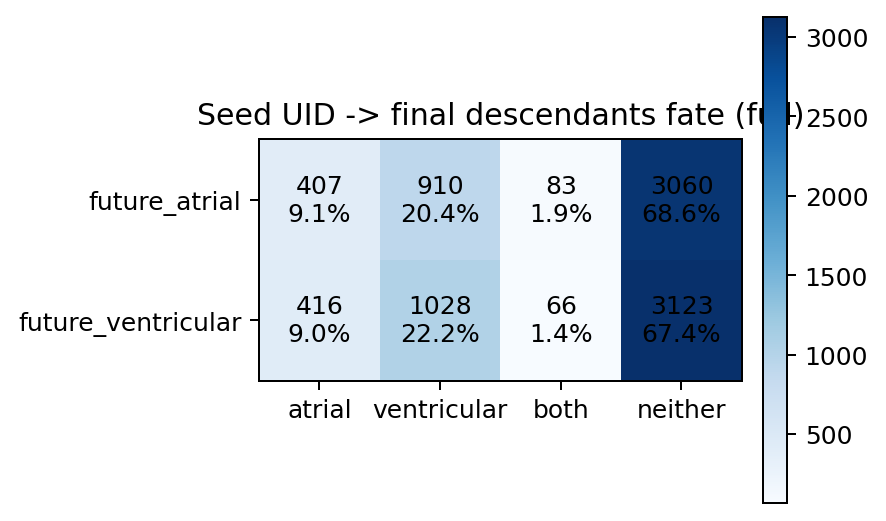

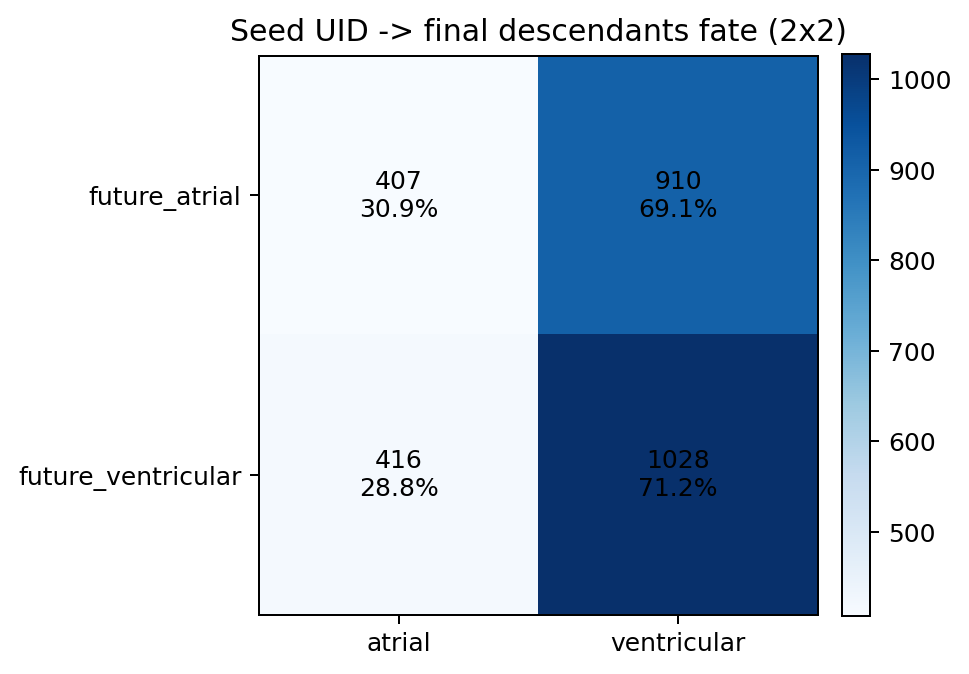

In [86]:
res_track = classify_terminal_cell_state_transition_per_seed(
    adata_hist,
    uid_dict=uid_dict,   # uid_dict returned by classify_lv_origin_cell-state transitions.
    layer_col="layer_name",
    atrial_label="Atrial cardiomyocytes",
    ventricular_label="Ventricular cardiomyocytes",
)

print("=== Terminal cell_state_transition statistics for each starting uid (full) ===")
print(res_track["conf_full"])
print(res_track["conf_full_pct"])

print("\n=== 2x2 table for pure atrial / pure ventricular cell_state_transitions ===")
print(res_track["conf_2x2"])
print(res_track["conf_2x2_pct"])

plot_confusion_like(
    res_track["conf_full"],
    res_track["conf_full_pct"],
    title="Seed UID -> final descendants cell_state_transition (full)"
)

plot_confusion_like(
    res_track["conf_2x2"],
    res_track["conf_2x2_pct"],
    title="Seed UID -> final descendants cell_state_transition (2x2)"
)

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, PowerNorm


def truncate_colormap(cmap, minval=0.22, maxval=1.0, n=256):
    return LinearSegmentedColormap.from_list(
        f"trunc_{cmap.name}",
        cmap(np.linspace(minval, maxval, n))
    )


def plot_confusion_like_pretty(
    mat,
    mat_pct=None,
    title="",
    figsize=(5.2, 4.2),
    dpi=200,
    cmap_name="Blues",
    cmap_min=0.22,     # Increase this value to reduce pale colors.
    gamma=0.75,        # Values below 1 darken low values.
    transparent=True,
    save=None,
):
    arr = mat.to_numpy(dtype=float)

    base_cmap = plt.get_cmap(cmap_name)
    cmap = truncate_colormap(base_cmap, minval=cmap_min, maxval=1.0)

    # Keep low values visible.
    vmin = np.nanmin(arr)
    vmax = np.nanmax(arr)
    norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    if transparent:
        fig.patch.set_alpha(0.0)
        ax.set_facecolor("none")

    im = ax.imshow(arr, cmap=cmap, norm=norm)

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(mat.columns, fontsize=12)
    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(mat.index, fontsize=12)
    ax.set_title(title, fontsize=16, pad=10)

    # Adjust grid lines and spine widths.
    ax.tick_params(length=4, width=1.0)

    # Automatically select the text color.
    threshold = (vmin + vmax) / 2.0
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = float(mat.iloc[i, j])
            txt_color = "white" if val > threshold else "black"

            if mat_pct is not None:
                pct = float(mat_pct.iloc[i, j]) * 100
                txt = f"{int(val)}\n{pct:.1f}%"
            else:
                txt = f"{int(val)}"

            ax.text(
                j, i, txt,
                ha="center", va="center",
                fontsize=13, color=txt_color
            )

    # cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # cbar.ax.tick_params(labelsize=11)
    # if transparent:
    #     cbar.ax.set_facecolor("none")

    plt.tight_layout()

    if save is not None:
        plt.savefig(save, dpi=dpi, bbox_inches="tight", transparent=transparent)

    plt.show()


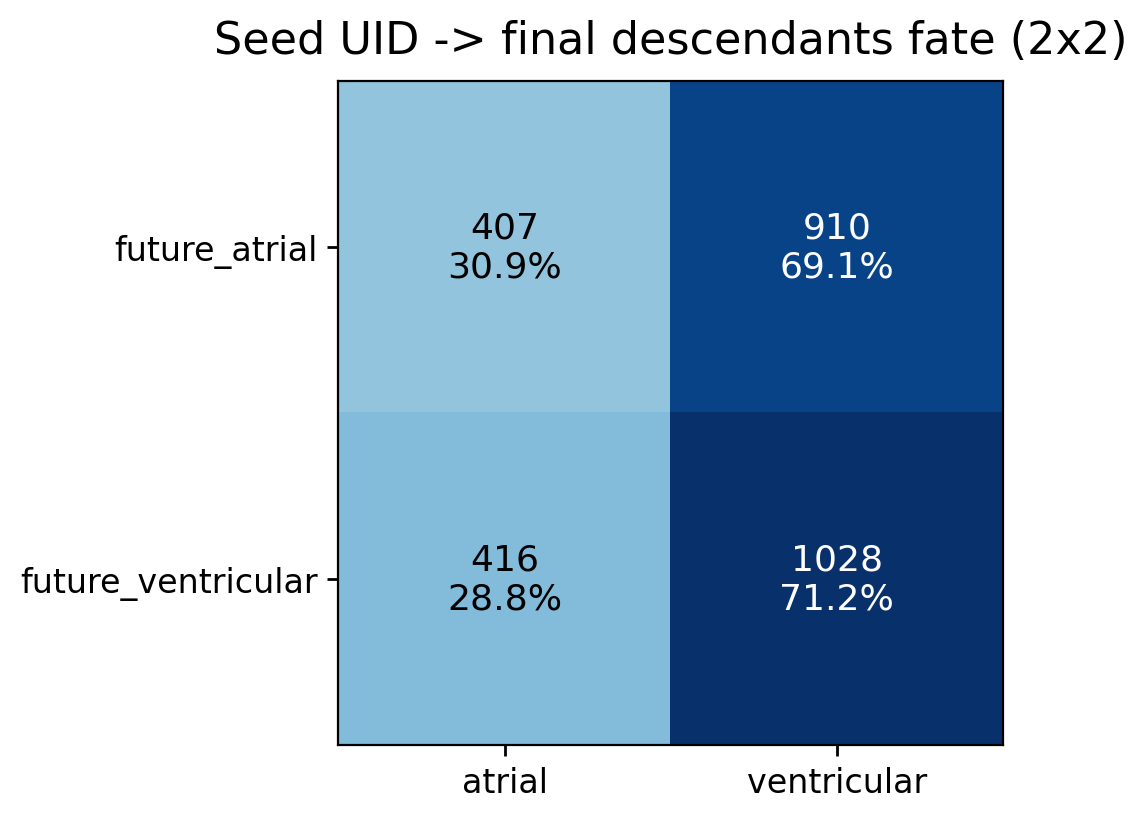

In [98]:
plot_confusion_like_pretty(
    res_track["conf_2x2"],
    res_track["conf_2x2_pct"],
    title="Seed UID -> final descendants cell_state_transition (2x2)",
    cmap_min=0.40,   
    gamma=0.64,     
    transparent=True,
)

In [200]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, PowerNorm


def truncate_colormap(cmap, minval=0.22, maxval=1.0, n=256):
    return LinearSegmentedColormap.from_list(
        f"trunc_{cmap.name}",
        cmap(np.linspace(minval, maxval, n))
    )


def plot_confusion_like_pretty(
    mat,
    mat_pct=None,
    title="",
    figsize=(5.2, 4.2),
    dpi=200,
    cmap_name="Blues",
    cmap_min=0.22,     # Increase this value to reduce pale colors.
    gamma=0.75,        # Values below 1 darken low values.
    transparent=True,
    save=None,
):
    arr = mat.to_numpy(dtype=float)

    base_cmap = plt.get_cmap(cmap_name)
    cmap = truncate_colormap(base_cmap, minval=cmap_min, maxval=1.0)

    # Keep low values visible.
    vmin = np.nanmin(arr)
    vmax = np.nanmax(arr)
    norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    if transparent:
        fig.patch.set_alpha(0.0)
        ax.set_facecolor("none")

    im = ax.imshow(arr, cmap=cmap, norm=norm)

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(mat.columns, fontsize=12)
    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(mat.index, fontsize=12)
    ax.set_title(title, fontsize=16, pad=10)

    # Adjust grid lines and spine widths.
    ax.tick_params(length=4, width=1.0)

    # # Automatically select the text color.
    # threshold = (vmin + vmax) / 2.0
    # for i in range(mat.shape[0]):
    #     for j in range(mat.shape[1]):
    #         val = float(mat.iloc[i, j])
    #         txt_color = "white" if val > threshold else "black"

    #         if mat_pct is not None:
    #             pct = float(mat_pct.iloc[i, j]) * 100
    #             txt = f"{int(val)}\n{pct:.1f}%"
    #         else:
    #             txt = f"{int(val)}"

    #         ax.text(
    #             j, i, txt,
    #             ha="center", va="center",
    #             fontsize=13, color=txt_color
    #         )

    # cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # cbar.ax.tick_params(labelsize=11)
    # if transparent:
    #     cbar.ax.set_facecolor("none")

    plt.tight_layout()

    if save is not None:
        plt.savefig(save, dpi=dpi, bbox_inches="tight", transparent=transparent)

    plt.show()


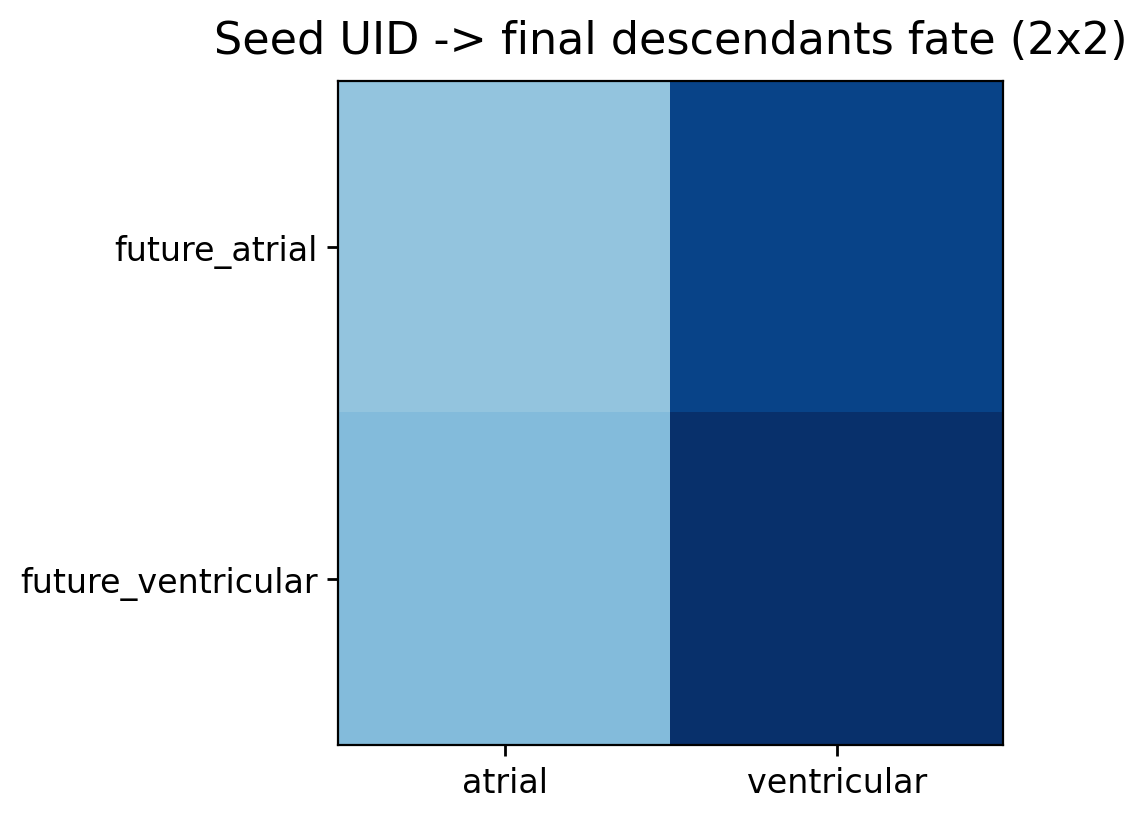

In [201]:
plot_confusion_like_pretty(
    res_track["conf_2x2"],
    res_track["conf_2x2_pct"],
    title="Seed UID -> final descendants cell_state_transition (2x2)",
    cmap_min=0.40,   
    gamma=0.64,     
    transparent=True,
)

## Decode and compare

Save decoded frames and compare marker expression with the baseline.


In [99]:
save_dir = session.decode()
adata_query_decode = read_frames(sorted(Path(save_dir).glob('*.h5ad')))
adata_query_decode

sample
counts_pred_sample_E9.5h_to_E11.5h_f0020_t1p0000    51671
counts_pred_sample_E9.5h_to_E11.5h_f0019_t0p9500    51334
counts_pred_sample_E9.5h_to_E11.5h_f0018_t0p9000    51016
counts_pred_sample_E9.5h_to_E11.5h_f0017_t0p8500    50694
counts_pred_sample_E9.5h_to_E11.5h_f0016_t0p8000    50364
counts_pred_sample_E9.5h_to_E11.5h_f0015_t0p7500    50026
counts_pred_sample_E9.5h_to_E11.5h_f0014_t0p7000    49682
counts_pred_sample_E9.5h_to_E11.5h_f0013_t0p6500    49335
counts_pred_sample_E9.5h_to_E11.5h_f0012_t0p6000    48987
counts_pred_sample_E9.5h_to_E11.5h_f0011_t0p5500    48638
counts_pred_sample_E9.5h_to_E11.5h_f0010_t0p5000    48287
counts_pred_sample_E9.5h_to_E11.5h_f0009_t0p4500    47931
counts_pred_sample_E9.5h_to_E11.5h_f0008_t0p4000    47571
counts_pred_sample_E9.5h_to_E11.5h_f0007_t0p3500    47211
counts_pred_sample_E9.5h_to_E11.5h_f0006_t0p3000    46849
counts_pred_sample_E9.5h_to_E11.5h_f0005_t0p2500    46484
counts_pred_sample_E9.5h_to_E11.5h_f0004_t0p2000    46117
counts_

AnnData object with n_obs × n_vars = 1012984 × 25
    obs: 'cx', 'cy', 'cz', 'layer_idx', 'layer_name', 'uid', 'parent_uid', 'is_birth', 'is_diff', 'diff_alpha', 'diff_tgt_layer', 'diff_tgt_layer_name', 'sample', 'frame', 'x_roll', 'y_roll'
    obsm: 'X_latent', 'spatial'
    layers: 'counts_hat', 'log1p_hat'

In [100]:
import numpy as np
import pandas as pd
import scipy.sparse as sp


def norm_uid(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s in {"", "nan", "NaN", "None"}:
        return None
    try:
        xf = float(s)
        if np.isfinite(xf) and xf.is_integer():
            return str(int(xf))
    except Exception:
        pass
    return s


def find_gene_name(adata, gene):
    if gene in adata.var_names:
        return gene
    low_map = {str(g).lower(): str(g) for g in adata.var_names}
    g2 = low_map.get(str(gene).lower(), None)
    if g2 is None:
        raise KeyError(f"Gene {gene!r} is not in adata.var_names")
    return g2


def annotate_seed_cell_state_transitions_on_decode_adata(
    adata,
    uid_dict,
    *,
    uid_col="uid",
    parent_uid_col="parent_uid",
    frame_col="frame",
    layer_col="layer_name",
    atrial_label="Atrial cardiomyocytes",
    ventricular_label="Ventricular cardiomyocytes",
):
    """
    Returns:
      obs_ann: annotation table indexed like adata.obs, with additional columns
          uid_norm, parent_uid_norm, root_seed, source_group, seed_terminal_cell-state transition
      seed_cell-state transition_df: terminal cell-state transition table with one row per root_seed
    """
    obs = adata.obs[[uid_col, parent_uid_col, frame_col, layer_col]].copy()

    obs["uid_norm"] = obs[uid_col].map(norm_uid)
    obs["parent_uid_norm"] = obs[parent_uid_col].map(norm_uid)
    obs["frame_num"] = pd.to_numeric(obs[frame_col], errors="coerce").astype(int)

    future_atrial = set(map(norm_uid, uid_dict.get("future_atrial", [])))
    future_ventricular = set(map(norm_uid, uid_dict.get("future_ventricular", [])))
    seed_uids = sorted(future_atrial | future_ventricular)

    # First appearance of each uid.
    birth_df = (
        obs[["uid_norm", "parent_uid_norm", "frame_num"]]
        .dropna(subset=["uid_norm"])
        .sort_values(["frame_num", "uid_norm"])
        .drop_duplicates(subset=["uid_norm"], keep="first")
        .copy()
    )

    first_frame = int(obs["frame_num"].min())
    frame0_uids = set(
        obs.loc[obs["frame_num"] == first_frame, "uid_norm"]
        .dropna().astype(str).tolist()
    )
    seed_uids = [u for u in seed_uids if u in frame0_uids]

    root_seed_of = {}

    for _, row in birth_df.iterrows():
        uid = row["uid_norm"]
        parent = row["parent_uid_norm"]

        if uid in seed_uids:
            root_seed_of[uid] = uid
        elif parent in root_seed_of:
            root_seed_of[uid] = root_seed_of[parent]

    obs["root_seed"] = obs["uid_norm"].map(lambda x: root_seed_of.get(x, None))

    def map_source_group(root_seed):
        if root_seed in future_atrial:
            return "future_atrial"
        if root_seed in future_ventricular:
            return "future_ventricular"
        return "other"

    obs["source_group"] = obs["root_seed"].map(map_source_group)

    # Determine each seed's cell-state transition in the terminal frame.
    final_frame = int(obs["frame_num"].max())
    final_obs = obs.loc[(obs["frame_num"] == final_frame) & (obs["root_seed"].notna())].copy()

    rows = []
    for root in seed_uids:
        sub = final_obs.loc[final_obs["root_seed"] == root].copy()
        layers = sub[layer_col].astype(str) if len(sub) > 0 else pd.Series([], dtype=str)

        has_a = bool((layers == atrial_label).any())
        has_v = bool((layers == ventricular_label).any())

        if has_a and not has_v:
            terminal_cell_state_transition = "atrial"
        elif has_v and not has_a:
            terminal_cell_state_transition = "ventricular"
        elif has_a and has_v:
            terminal_cell_state_transition = "both"
        else:
            terminal_cell_state_transition = "neither"

        rows.append({
            "root_seed": root,
            "source_group": map_source_group(root),
            "seed_terminal_cell_state_transition": terminal_cell_state_transition,
            "n_final_descendants": int(len(sub)),
            "n_atrial_final": int((layers == atrial_label).sum()) if len(sub) > 0 else 0,
            "n_ventricular_final": int((layers == ventricular_label).sum()) if len(sub) > 0 else 0,
        })

    seed_cell_state_transition_df = pd.DataFrame(rows)

    seed_to_terminal = dict(zip(seed_cell_state_transition_df["root_seed"], seed_cell_state_transition_df["seed_terminal_cell_state_transition"]))
    obs["seed_terminal_cell_state_transition"] = obs["root_seed"].map(lambda x: seed_to_terminal.get(x, "untracked"))

    return obs, seed_cell_state_transition_df

In [103]:
adata_query_decode.obs['t'] = adata_query_decode.obs['frame'].astype(int)

In [104]:
obs_ann, seed_cell_state_transition_df = annotate_seed_cell_state_transitions_on_decode_adata(
    adata_query_decode,
    uid_dict=uid_dict,
    uid_col="uid",
    parent_uid_col="parent_uid",
    frame_col="t",
    layer_col="layer_name",
    atrial_label="Atrial cardiomyocytes",
    ventricular_label="Ventricular cardiomyocytes",
)

print(seed_cell_state_transition_df["source_group"].value_counts())
print(seed_cell_state_transition_df["seed_terminal_cell_state_transition"].value_counts())

source_group
future_ventricular    4633
future_atrial         4460
Name: count, dtype: int64
seed_terminal_cell_state_transition
neither        5527
ventricular    2386
atrial          991
both            189
Name: count, dtype: int64


In [ ]:
def extract_gene_vector(adata, obs_index, gene, layer="log1p_hat"):
    gene = find_gene_name(adata, gene)
    gi = adata.var_names.get_loc(gene)

    X = adata.layers[layer] if (layer is not None and layer in adata.layers) else adata.X
    row_idx = adata.obs_names.get_indexer(obs_index)

    vals = X[row_idx, gi]
    if sp.issparse(vals):
        vals = vals.A1
    else:
        vals = np.asarray(vals).reshape(-1)

    return vals.astype(np.float32), gene


def build_boxplot_df_for_source_group(
    adata,
    obs_ann,
    *,
    source_group,
    genes=("Myl7", "Myh7"),
    layer="log1p_hat",
    frame_col="frame_num",
    sample_n_per_group_per_frame=1500,
    random_state=2025,
):
    """
    source_group:
      'future_atrial' or 'future_ventricular'
    Keep the two groups with seed_terminal_cell-state transition atrial / ventricular.
    """
    df = obs_ann.copy()

    keep = (
        (df["source_group"] == source_group) &
        (df["seed_terminal_cell_state_transition"].isin(["atrial", "ventricular"]))
    )
    df = df.loc[keep, [frame_col, "seed_terminal_cell_state_transition"]].copy()
    df[frame_col] = pd.to_numeric(df[frame_col], errors="coerce").astype(int)

    # Downsample each frame and group for large datasets.
    if sample_n_per_group_per_frame is not None:
        rng = np.random.default_rng(random_state)
        keep_idx = []

        for (_, _), sub_idx in df.groupby([frame_col, "seed_terminal_cell_state_transition"]).groups.items():
            sub_idx = np.array(list(sub_idx))
            if len(sub_idx) > sample_n_per_group_per_frame:
                sub_idx = rng.choice(sub_idx, size=sample_n_per_group_per_frame, replace=False)
            keep_idx.extend(sub_idx.tolist())

        df = df.loc[keep_idx].copy()

    long_list = []
    for gene in genes:
        expr, gene_real = extract_gene_vector(
            adata,
            obs_index=df.index,
            gene=gene,
            layer=layer,
        )
        tmp = df.copy()
        tmp["gene"] = gene_real
        tmp["expr"] = expr
        long_list.append(tmp)

    plot_df = pd.concat(long_list, axis=0).reset_index().rename(columns={"index": "cell_id"})
    return plot_df
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_marker_boxplots_by_cell_state_transition(
    plot_df,
    *,
    source_group,
    genes=("Myl7", "Myh7"),
    out_dir=None,
    frame_col="frame_num",
    expr_col="expr",
    cell_state_transition_col="seed_terminal_cell_state_transition",
    group1="atrial",
    group2="ventricular",
    ylabel="Decoded expression",
    palette=None,
    showfliers=False,
    figsize=(8.6, 4.8),
    dpi=220,
):
    """
    Use the plotting style of plot_lr_boxplots_by_pair:
    - Transparent background.
    - Offset the two groups of boxplots horizontally.
    - Use the same color for each box and its border.
    - White median lines.
    - Connect median values with a trend line.
    """

    if palette is None:
        palette = {
            str(group1): "#00cfff",   # atrial
            str(group2): "#ff4d6d",   # ventricular
        }

    genes_real = [g for g in genes if g in plot_df["gene"].unique()]
    if len(genes_real) == 0:
        raise ValueError("plot_df contains no genes to plot")

    frames = sorted(plot_df[frame_col].dropna().astype(int).unique().tolist())

    if out_dir is not None:
        os.makedirs(out_dir, exist_ok=True)

    for gene in genes_real:
        dfp = plot_df.loc[
            (plot_df["gene"] == str(gene)) &
            (plot_df[cell_state_transition_col].isin([str(group1), str(group2)])) &
            (plot_df[frame_col].isin(frames))
        ].copy()

        if len(dfp) == 0:
            print(f"[skip] {source_group} | {gene}: no data")
            continue

        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

        # Transparent background.
        fig.patch.set_alpha(0)
        ax.set_facecolor("none")

        width = 0.30
        offset = 0.18

        pos1 = np.array(frames, dtype=float) - offset
        pos2 = np.array(frames, dtype=float) + offset

        data1 = [
            dfp.loc[
                (dfp[frame_col] == fr) &
                (dfp[cell_state_transition_col] == str(group1)),
                expr_col
            ].dropna().to_numpy()
            for fr in frames
        ]

        data2 = [
            dfp.loc[
                (dfp[frame_col] == fr) &
                (dfp[cell_state_transition_col] == str(group2)),
                expr_col
            ].dropna().to_numpy()
            for fr in frames
        ]

        ax.boxplot(
            data1,
            positions=pos1,
            widths=width,
            patch_artist=True,
            showfliers=showfliers,
            medianprops=dict(color="white", linewidth=1.2),
            boxprops=dict(
                facecolor=palette[str(group1)],
                edgecolor=palette[str(group1)],
                alpha=0.8,
                linewidth=1.0
            ),
            whiskerprops=dict(color=palette[str(group1)], linewidth=1.0),
            capprops=dict(color=palette[str(group1)], linewidth=1.0),
        )

        ax.boxplot(
            data2,
            positions=pos2,
            widths=width,
            patch_artist=True,
            showfliers=showfliers,
            medianprops=dict(color="white", linewidth=1.2),
            boxprops=dict(
                facecolor=palette[str(group2)],
                edgecolor=palette[str(group2)],
                alpha=0.8,
                linewidth=1.0
            ),
            whiskerprops=dict(color=palette[str(group2)], linewidth=1.0),
            capprops=dict(color=palette[str(group2)], linewidth=1.0),
        )

        # Median trend line.
        med1 = [np.nanmedian(x) if len(x) > 0 else np.nan for x in data1]
        med2 = [np.nanmedian(x) if len(x) > 0 else np.nan for x in data2]

        ax.plot(pos1, med1, color=palette[str(group1)], linewidth=1.8, alpha=0.95)
        ax.plot(pos2, med2, color=palette[str(group2)], linewidth=1.8, alpha=0.95)

        ax.set_xticks(frames)
        ax.set_xticklabels(frames)
        ax.set_xlabel("Frame", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f"{source_group} | {gene}", fontsize=12, pad=10)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        handles = [
            plt.Line2D([0], [0], color=palette[str(group1)], lw=2, label=str(group1)),
            plt.Line2D([0], [0], color=palette[str(group2)], lw=2, label=str(group2)),
        ]
        ax.legend(handles=handles, frameon=False, loc="upper right")

        plt.tight_layout()

        if out_dir is not None:
            save_path = os.path.join(
                out_dir,
                f"{source_group}_{gene}_boxplot.png".replace("/", "_").replace(" ", "_")
            )
            plt.savefig(save_path, bbox_inches="tight", transparent=True)

        plt.show()

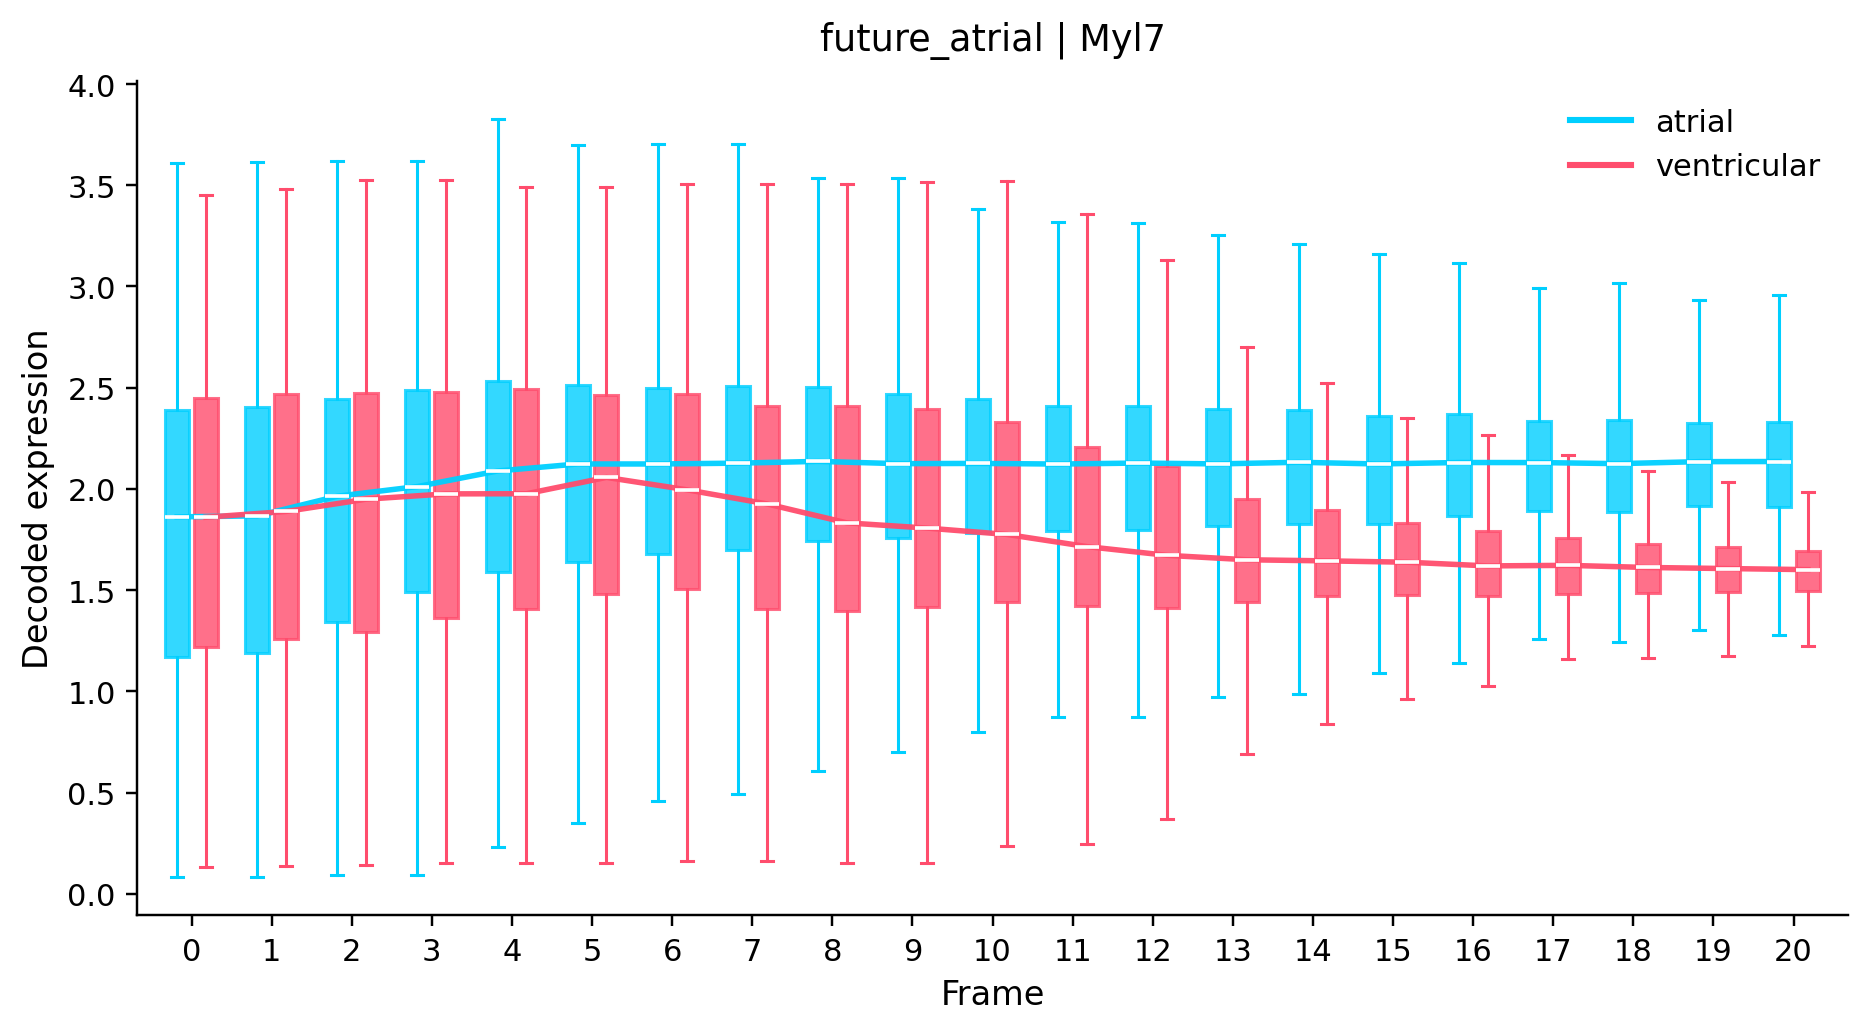

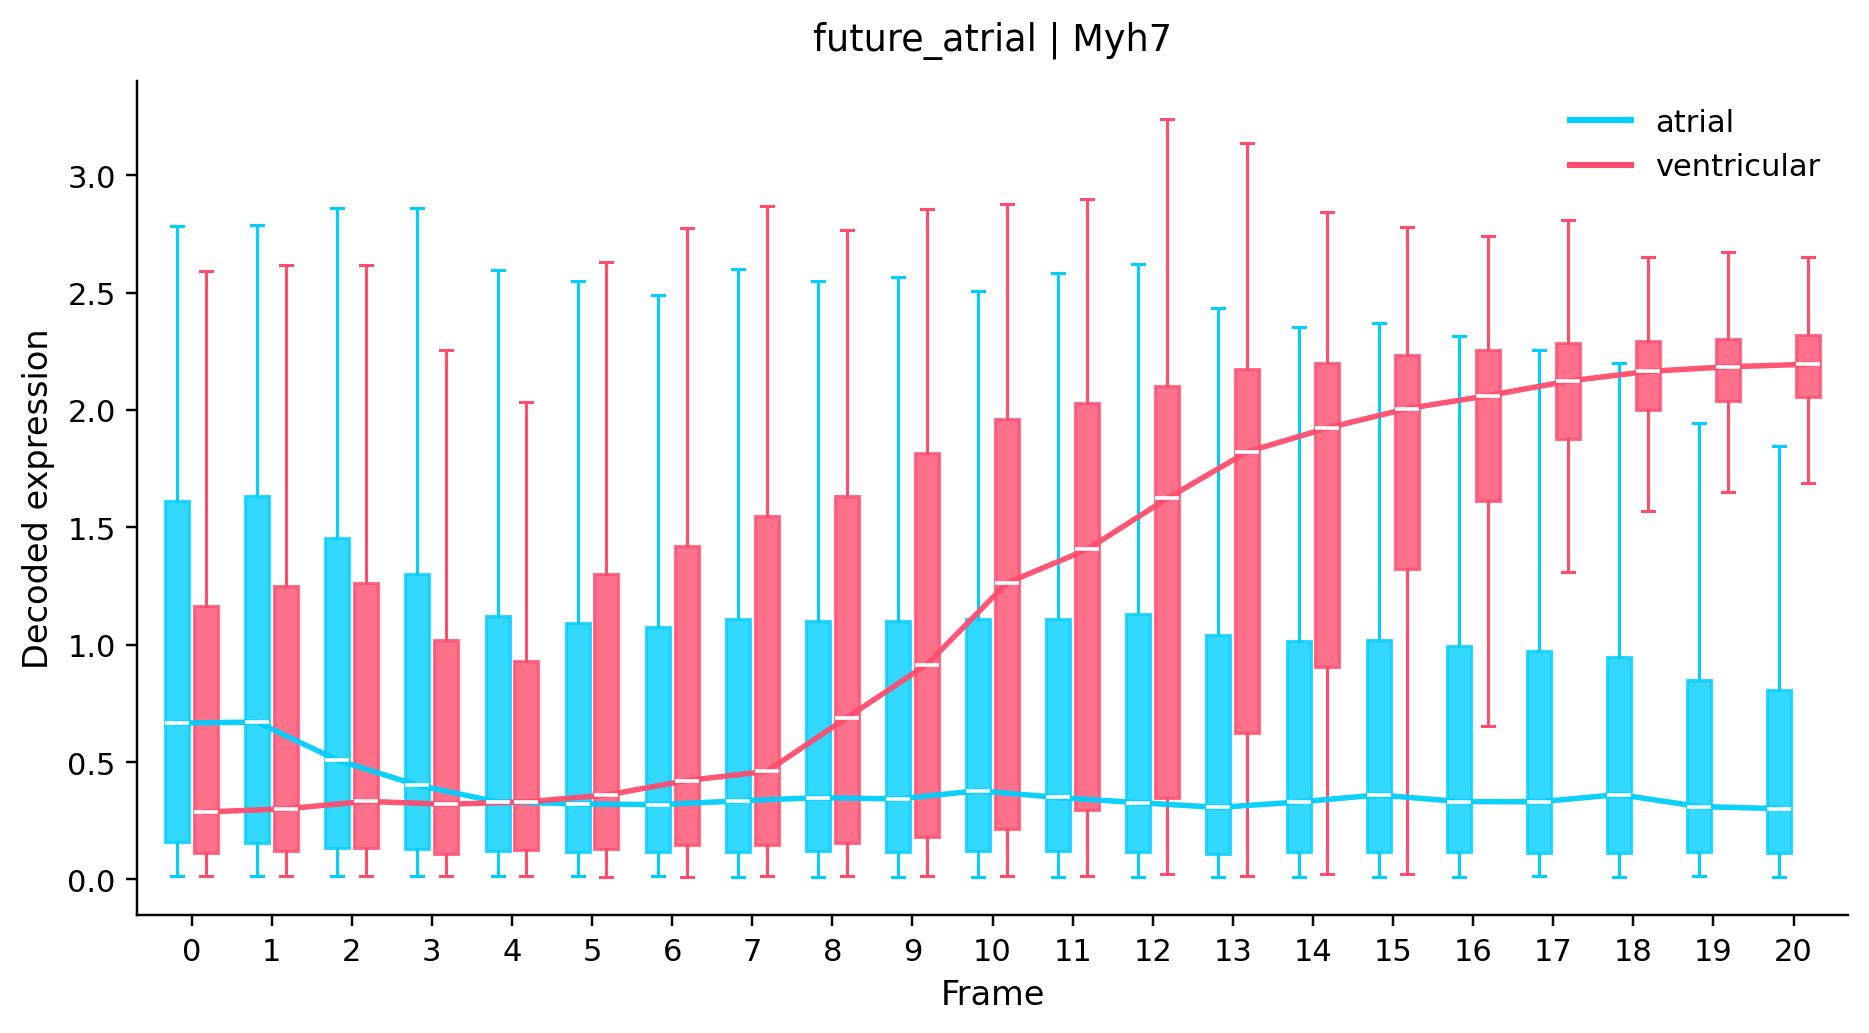

None


In [128]:
plot_df_atrial = build_boxplot_df_for_source_group(
    adata_query_decode,
    obs_ann,
    source_group="future_atrial",
    genes=("Myl7", "Myh7"),
    layer="log1p_hat",
    frame_col="frame_num",
    sample_n_per_group_per_frame=1500,   # Reduce this value, for example to 800, for faster sampling.
    random_state=2025,
)

p_global_atrial = plot_marker_boxplots_by_cell_state_transition(
    plot_df_atrial,
    source_group="future_atrial",
    genes=("Myl7", "Myh7"),
    out_dir=str(session.start() / 'marker_boxplots_atrial'),
    frame_col="frame_num",
    expr_col="expr",
    cell_state_transition_col="seed_terminal_cell_state_transition",
    group1="atrial",
    group2="ventricular",
    ylabel="Decoded expression",
    showfliers=False,
)
print(p_global_atrial)

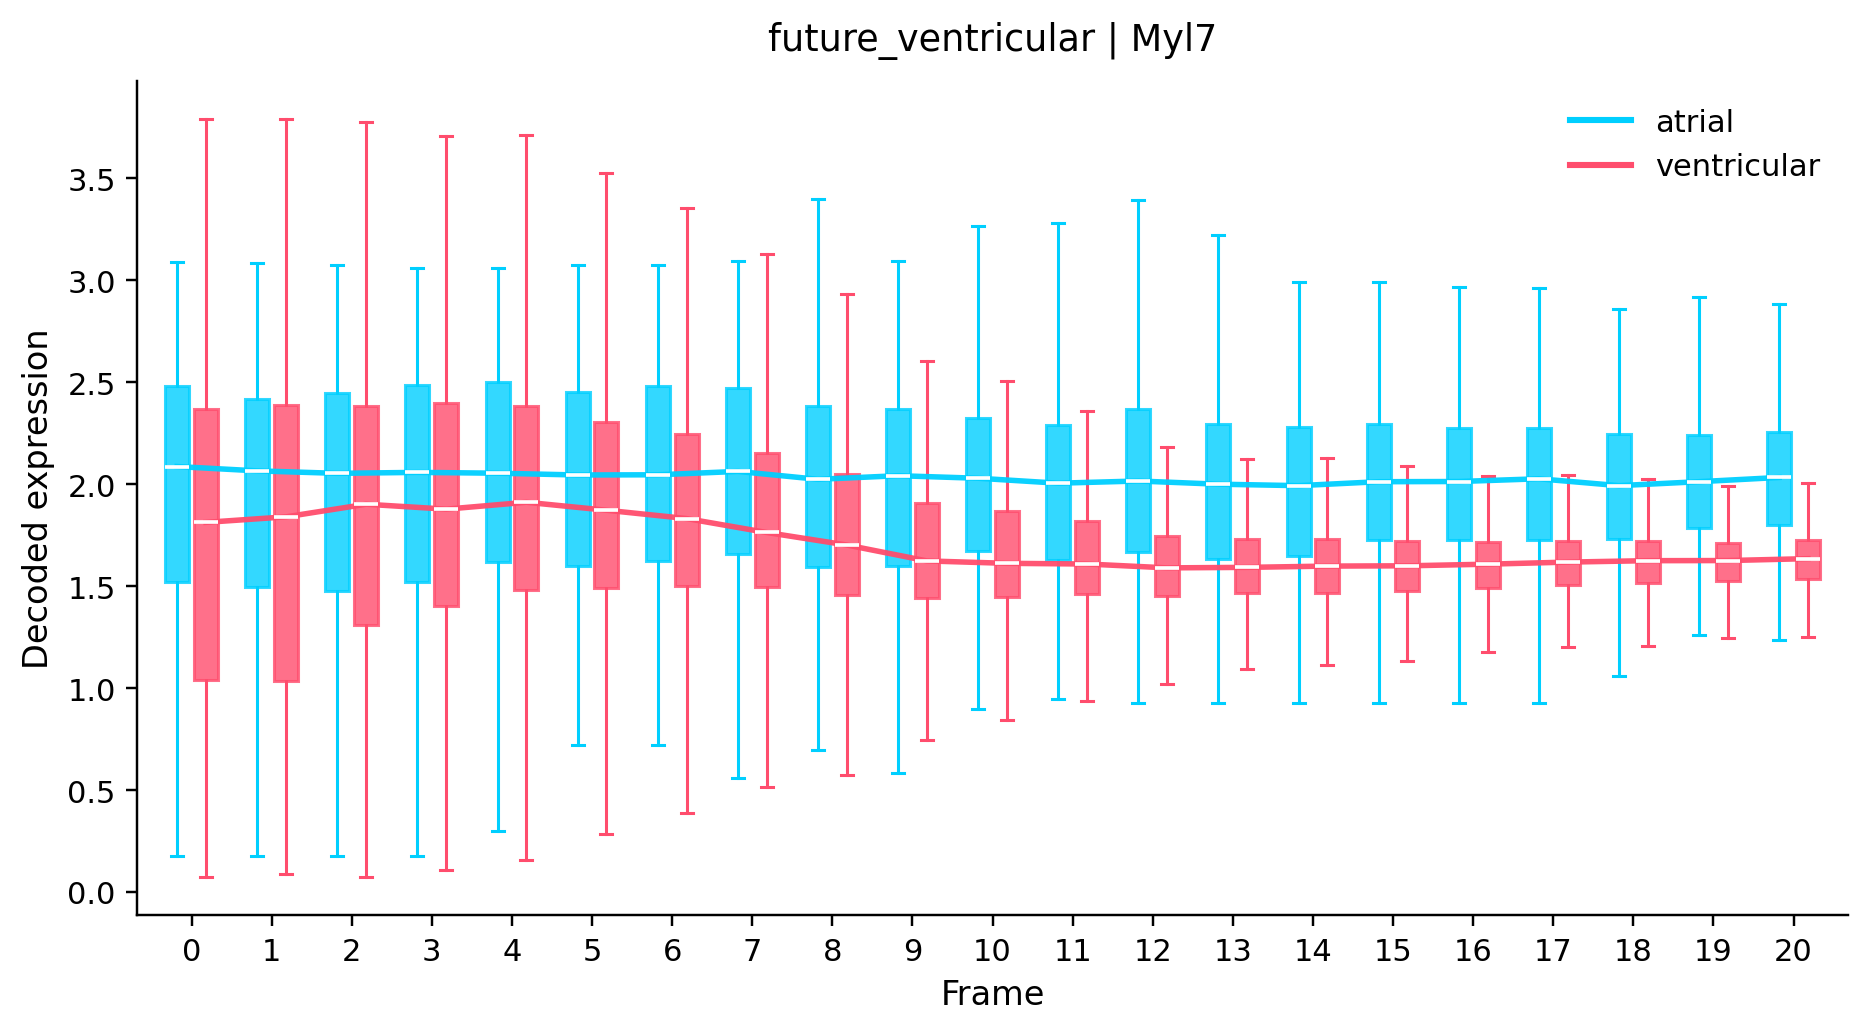

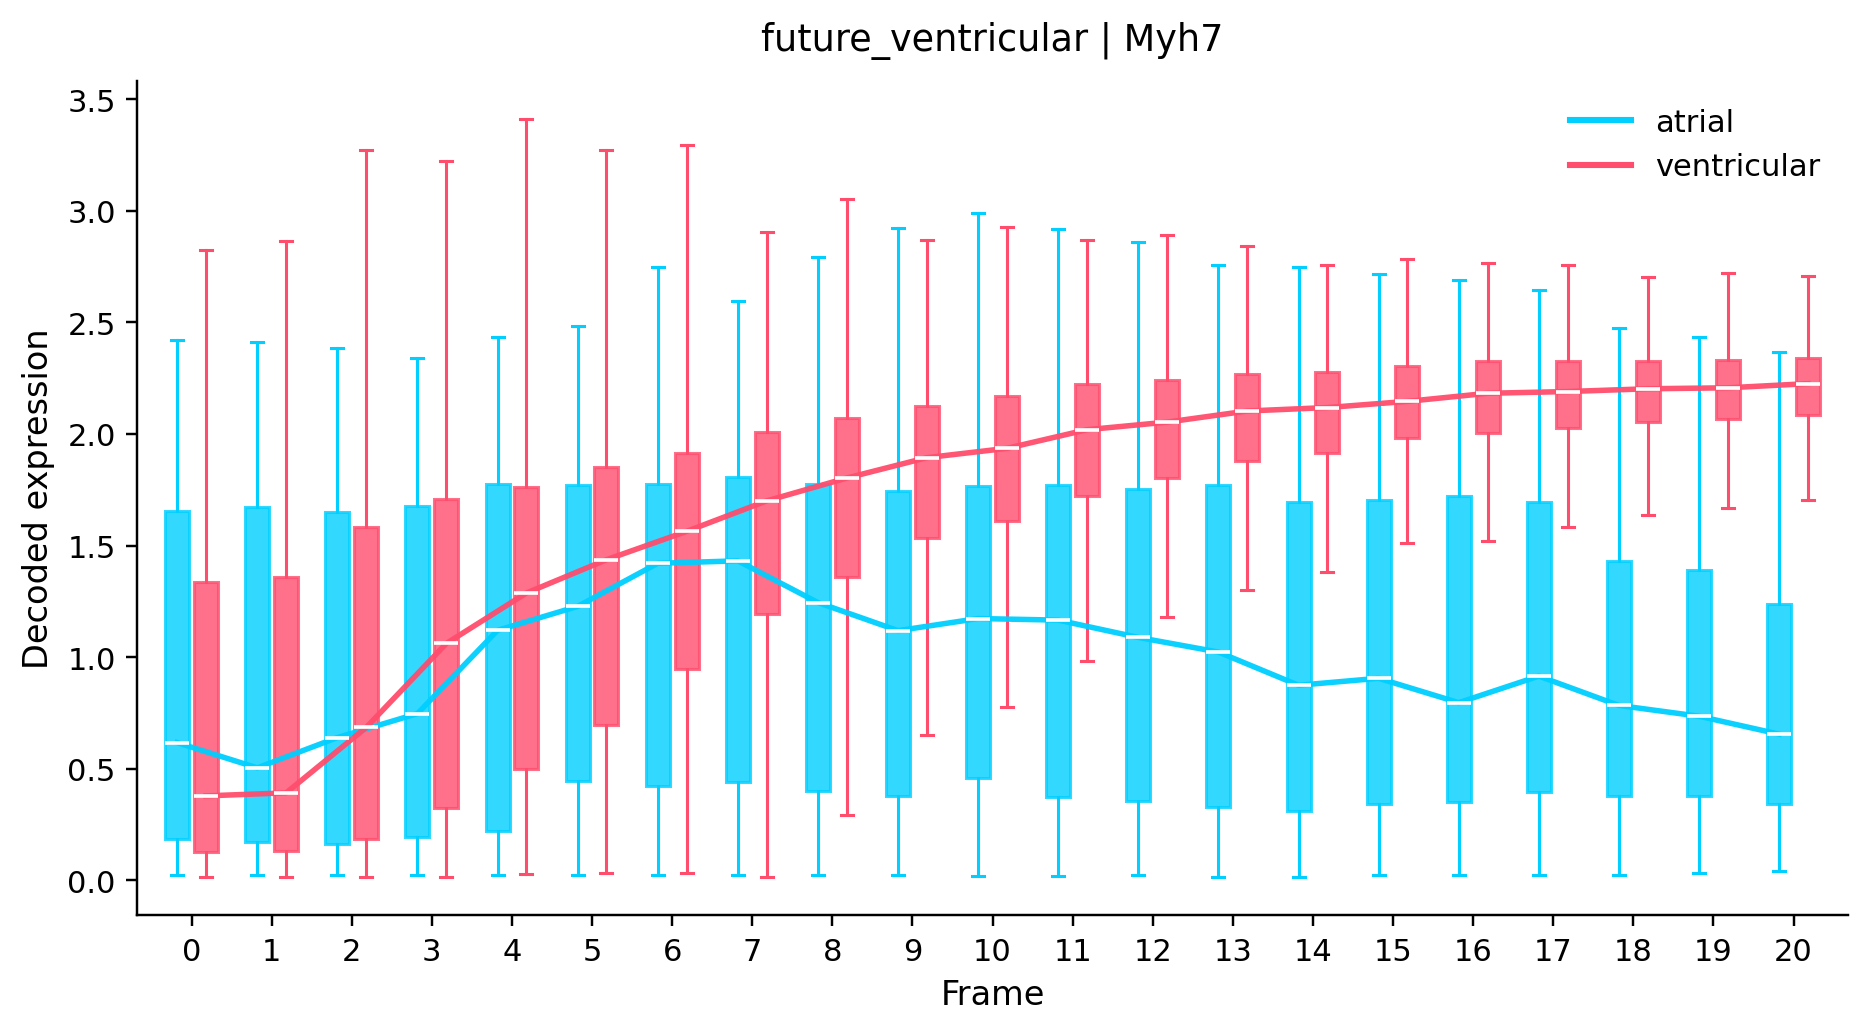

In [129]:
plot_df_vent = build_boxplot_df_for_source_group(
    adata_query_decode,
    obs_ann,
    source_group="future_ventricular",
    genes=("Myl7", "Myh7"),
    layer="log1p_hat",
    frame_col="frame_num",
    sample_n_per_group_per_frame=1500,
    random_state=2025,
)

plot_marker_boxplots_by_cell_state_transition(
    plot_df_vent,
    source_group="future_ventricular",
    genes=("Myl7", "Myh7"),
    out_dir=str(session.start() / 'marker_boxplots_ventricular'),
    frame_col="frame_num",
    expr_col="expr",
    cell_state_transition_col="seed_terminal_cell_state_transition",
    group1="atrial",
    group2="ventricular",
    ylabel="Decoded expression",
    showfliers=False,
)

In [130]:
baseline_decoded = session.decode(baseline=True)
adata_ori = read_frames(sorted(Path(baseline_decoded).glob('*.h5ad')))
adata_ori

sample
counts_pred_sample_E9.5h_to_E11.5h_f0020_t1p0000    51671
counts_pred_sample_E9.5h_to_E11.5h_f0021_t1p1000    51671
counts_pred_sample_E9.5h_to_E11.5h_f0019_t0p9500    51334
counts_pred_sample_E9.5h_to_E11.5h_f0018_t0p9000    51016
counts_pred_sample_E9.5h_to_E11.5h_f0017_t0p8500    50694
counts_pred_sample_E9.5h_to_E11.5h_f0016_t0p8000    50364
counts_pred_sample_E9.5h_to_E11.5h_f0015_t0p7500    50026
counts_pred_sample_E9.5h_to_E11.5h_f0014_t0p7000    49682
counts_pred_sample_E9.5h_to_E11.5h_f0013_t0p6500    49335
counts_pred_sample_E9.5h_to_E11.5h_f0012_t0p6000    48987
counts_pred_sample_E9.5h_to_E11.5h_f0011_t0p5500    48638
counts_pred_sample_E9.5h_to_E11.5h_f0010_t0p5000    48287
counts_pred_sample_E9.5h_to_E11.5h_f0009_t0p4500    47931
counts_pred_sample_E9.5h_to_E11.5h_f0008_t0p4000    47571
counts_pred_sample_E9.5h_to_E11.5h_f0007_t0p3500    47211
counts_pred_sample_E9.5h_to_E11.5h_f0006_t0p3000    46849
counts_pred_sample_E9.5h_to_E11.5h_f0005_t0p2500    46484
counts_

AnnData object with n_obs × n_vars = 1064655 × 25
    obs: 'layer_name', 'uid', 'sample'
    obsm: 'spatial'
    layers: 'counts_hat', 'log1p_hat'

In [131]:
adata_ori.obs['t'] = adata_ori.obs['frame'].astype(int)

In [142]:
import numpy as np
import pandas as pd
import scipy.sparse as sp


def norm_uid(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s in {"", "nan", "NaN", "None"}:
        return None
    try:
        xf = float(s)
        if np.isfinite(xf) and xf.is_integer():
            return str(int(xf))
    except Exception:
        pass
    return s


def find_gene_name(adata, gene):
    if gene in adata.var_names:
        return gene
    low_map = {str(g).lower(): str(g) for g in adata.var_names}
    g2 = low_map.get(str(gene).lower(), None)
    if g2 is None:
        raise KeyError(f"Gene {gene!r} is not in adata.var_names")
    return g2


def extract_gene_vector_general(
    adata,
    obs_index,
    gene,
    layer=None,
    log1p_transform=False,
):
    gene = find_gene_name(adata, gene)
    gi = adata.var_names.get_loc(gene)

    X = adata.layers[layer] if (layer is not None and layer in adata.layers) else adata.X
    row_idx = adata.obs_names.get_indexer(obs_index)

    vals = X[row_idx, gi]
    if sp.issparse(vals):
        vals = vals.A1
    else:
        vals = np.asarray(vals).reshape(-1)

    vals = vals.astype(np.float32)

    if log1p_transform:
        vals = np.log1p(np.clip(vals, a_min=0, a_max=None)).astype(np.float32)

    return vals, gene


def build_ori_control_df_for_source_group_over_time(
    adata_ori,
    uid_dict,
    *,
    source_group,
    genes=("Myl7", "Myh7"),
    uid_col="uid",
    time_col="t",          # Prefer t.
    frame_fallback="frame",
    drop_times=(21,),      # Exclude t == 21.
    layer=None,
    log1p_transform=False,
    control_label="ori",
    sample_n_per_time=None,
    random_state=2025,
):
    """
    Use trajectories of the same seed uids in adata_ori as the gray control.
    """
    obs = adata_ori.obs.copy()

    if uid_col not in obs.columns:
        raise KeyError(f"adata_ori.obs is missing {uid_col}")

    if time_col in obs.columns:
        use_time_col = time_col
    elif frame_fallback in obs.columns:
        use_time_col = frame_fallback
    else:
        raise KeyError(f"adata_ori.obs has neither {time_col} nor {frame_fallback}")

    seed_uids = set(map(norm_uid, uid_dict.get(source_group, [])))

    obs["uid_norm"] = obs[uid_col].map(norm_uid)
    obs["time_num"] = pd.to_numeric(obs[use_time_col], errors="coerce")

    df = obs.loc[
        obs["uid_norm"].isin(seed_uids) &
        obs["time_num"].notna()
    ].copy()

    df["time_num"] = df["time_num"].astype(int)

    if drop_times is not None and len(drop_times) > 0:
        drop_times = set(int(x) for x in drop_times)
        df = df.loc[~df["time_num"].isin(drop_times)].copy()

    if len(df) == 0:
        raise ValueError(
            f"No trajectories were found in adata_ori for source_group={source_group}"
        )

    # Optional: downsample each time point in the original control.
    if sample_n_per_time is not None:
        rng = np.random.default_rng(random_state)
        keep_idx = []
        for t, sub_idx in df.groupby("time_num").groups.items():
            sub_idx = np.array(list(sub_idx))
            if len(sub_idx) > sample_n_per_time:
                sub_idx = rng.choice(sub_idx, size=sample_n_per_time, replace=False)
            keep_idx.extend(sub_idx.tolist())
        df = df.loc[keep_idx].copy()

    long_list = []
    for gene in genes:
        expr, gene_real = extract_gene_vector_general(
            adata_ori,
            obs_index=df.index,
            gene=gene,
            layer=layer,
            log1p_transform=log1p_transform,
        )
        tmp = pd.DataFrame({
            "cell_id": df.index.astype(str),
            "frame_num": df["time_num"].to_numpy().astype(int),  # Unified frame_num column for plotting.
            "seed_terminal_cell_state_transition": control_label,
            "gene": gene_real,
            "expr": expr,
        })
        long_list.append(tmp)

    plot_df_ori = pd.concat(long_list, axis=0, ignore_index=True)
    return plot_df_ori

In [143]:
plot_df_ori_atrial = build_ori_control_df_for_source_group_over_time(
    adata_ori,
    uid_dict,
    source_group="future_atrial",
    genes=("Myl7", "Myh7"),
    uid_col="uid",
    time_col="t",          # Use t when available in adata_ori.
    frame_fallback="frame",
    drop_times=(21,),
    layer="counts" if "counts" in adata_ori.layers else None,
    log1p_transform=True,
)

In [144]:
plot_df_ori_vent = build_ori_control_df_for_source_group_over_time(
    adata_ori,
    uid_dict,
    source_group="future_ventricular",
    genes=("Myl7", "Myh7"),
    uid_col="uid",
    time_col="t",
    frame_fallback="frame",
    drop_times=(21,),
    layer="counts" if "counts" in adata_ori.layers else None,
    log1p_transform=True,
)

In [165]:
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_marker_boxplots_by_cell_state_transition_with_ori(
    plot_df,
    *,
    source_group,
    genes=("Myl7", "Myh7"),
    plot_df_ori=None,
    out_dir=None,
    frame_col="frame_num",
    expr_col="expr",
    cell_state_transition_col="seed_terminal_cell_state_transition",
    group0="ori",
    group1="atrial",
    group2="ventricular",
    ylabel="Decoded expression",
    palette=None,
    showfliers=False,
    figsize=(20, 5.0),
    dpi=220,
):
    if palette is None:
        palette = {
            str(group0): "#9e9e9e",
            str(group1): "#00cfff",
            str(group2): "#ff4d6d",
        }

    genes_real = [g for g in genes if g in plot_df["gene"].unique()]
    if plot_df_ori is not None:
        genes_real = [g for g in genes_real if g in plot_df_ori["gene"].unique()]
    if len(genes_real) == 0:
        raise ValueError("plot_df / plot_df_ori contains no genes to plot")

    frames = sorted(plot_df[frame_col].dropna().astype(int).unique().tolist())
    if plot_df_ori is not None and len(plot_df_ori) > 0:
        frames_ori = sorted(plot_df_ori[frame_col].dropna().astype(int).unique().tolist())
        frames = sorted(set(frames) | set(frames_ori))

    if out_dir is not None:
        os.makedirs(out_dir, exist_ok=True)

    for gene in genes_real:
        dfp = plot_df.loc[
            (plot_df["gene"] == str(gene)) &
            (plot_df[cell_state_transition_col].isin([str(group1), str(group2)])) &
            (plot_df[frame_col].isin(frames))
        ].copy()

        if plot_df_ori is not None:
            dfo = plot_df_ori.loc[
                (plot_df_ori["gene"] == str(gene)) &
                (plot_df_ori[cell_state_transition_col] == str(group0)) &
                (plot_df_ori[frame_col].isin(frames))
            ].copy()
        else:
            dfo = None

        if len(dfp) == 0 and (dfo is None or len(dfo) == 0):
            print(f"[skip] {source_group} | {gene}: no data")
            continue

        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        fig.patch.set_alpha(0)
        ax.set_facecolor("none")

        # Use narrower boxes and more spacing within each group.
        width = 0.25
        offset = 0.35

        pos0 = np.array(frames, dtype=float)
        pos1 = np.array(frames, dtype=float) - offset
        pos2 = np.array(frames, dtype=float) + offset

        # ori
        if dfo is not None and len(dfo) > 0:
            data0 = [
                dfo.loc[dfo[frame_col] == fr, expr_col].dropna().to_numpy()
                for fr in frames
            ]

            ax.boxplot(
                data0,
                positions=pos0,
                widths=width,
                patch_artist=True,
                showfliers=showfliers,
                medianprops=dict(color="white", linewidth=1.2),
                boxprops=dict(
                    facecolor=palette[str(group0)],
                    edgecolor=palette[str(group0)],
                    alpha=0.8,
                    linewidth=1.0
                ),
                whiskerprops=dict(color=palette[str(group0)], linewidth=1.0),
                capprops=dict(color=palette[str(group0)], linewidth=1.0),
            )

        # atrial
        data1 = [
            dfp.loc[
                (dfp[frame_col] == fr) &
                (dfp[cell_state_transition_col] == str(group1)),
                expr_col
            ].dropna().to_numpy()
            for fr in frames
        ]

        ax.boxplot(
            data1,
            positions=pos1,
            widths=width,
            patch_artist=True,
            showfliers=showfliers,
            medianprops=dict(color="white", linewidth=1.2),
            boxprops=dict(
                facecolor=palette[str(group1)],
                edgecolor=palette[str(group1)],
                alpha=0.8,
                linewidth=1.0
            ),
            whiskerprops=dict(color=palette[str(group1)], linewidth=1.0),
            capprops=dict(color=palette[str(group1)], linewidth=1.0),
        )

        # ventricular
        data2 = [
            dfp.loc[
                (dfp[frame_col] == fr) &
                (dfp[cell_state_transition_col] == str(group2)),
                expr_col
            ].dropna().to_numpy()
            for fr in frames
        ]

        ax.boxplot(
            data2,
            positions=pos2,
            widths=width,
            patch_artist=True,
            showfliers=showfliers,
            medianprops=dict(color="white", linewidth=1.2),
            boxprops=dict(
                facecolor=palette[str(group2)],
                edgecolor=palette[str(group2)],
                alpha=0.8,
                linewidth=1.0
            ),
            whiskerprops=dict(color=palette[str(group2)], linewidth=1.0),
            capprops=dict(color=palette[str(group2)], linewidth=1.0),
        )

        ax.set_xticks(frames)
        ax.set_xticklabels(frames)
        ax.set_xlabel("Frame", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f"{source_group} | {gene}", fontsize=12, pad=10)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        handles = [
            plt.Line2D([0], [0], color=palette[str(group0)], lw=2, label=str(group0)),
            plt.Line2D([0], [0], color=palette[str(group1)], lw=2, label=str(group1)),
            plt.Line2D([0], [0], color=palette[str(group2)], lw=2, label=str(group2)),
        ]
        # ax.legend(handles=handles, frameon=False, loc="upper right")

        plt.tight_layout()

        if out_dir is not None:
            save_path = os.path.join(
                out_dir,
                f"{source_group}_{gene}_boxplot_with_ori.png".replace("/", "_").replace(" ", "_")
            )
            plt.savefig(save_path, bbox_inches="tight", transparent=True)

        plt.show()

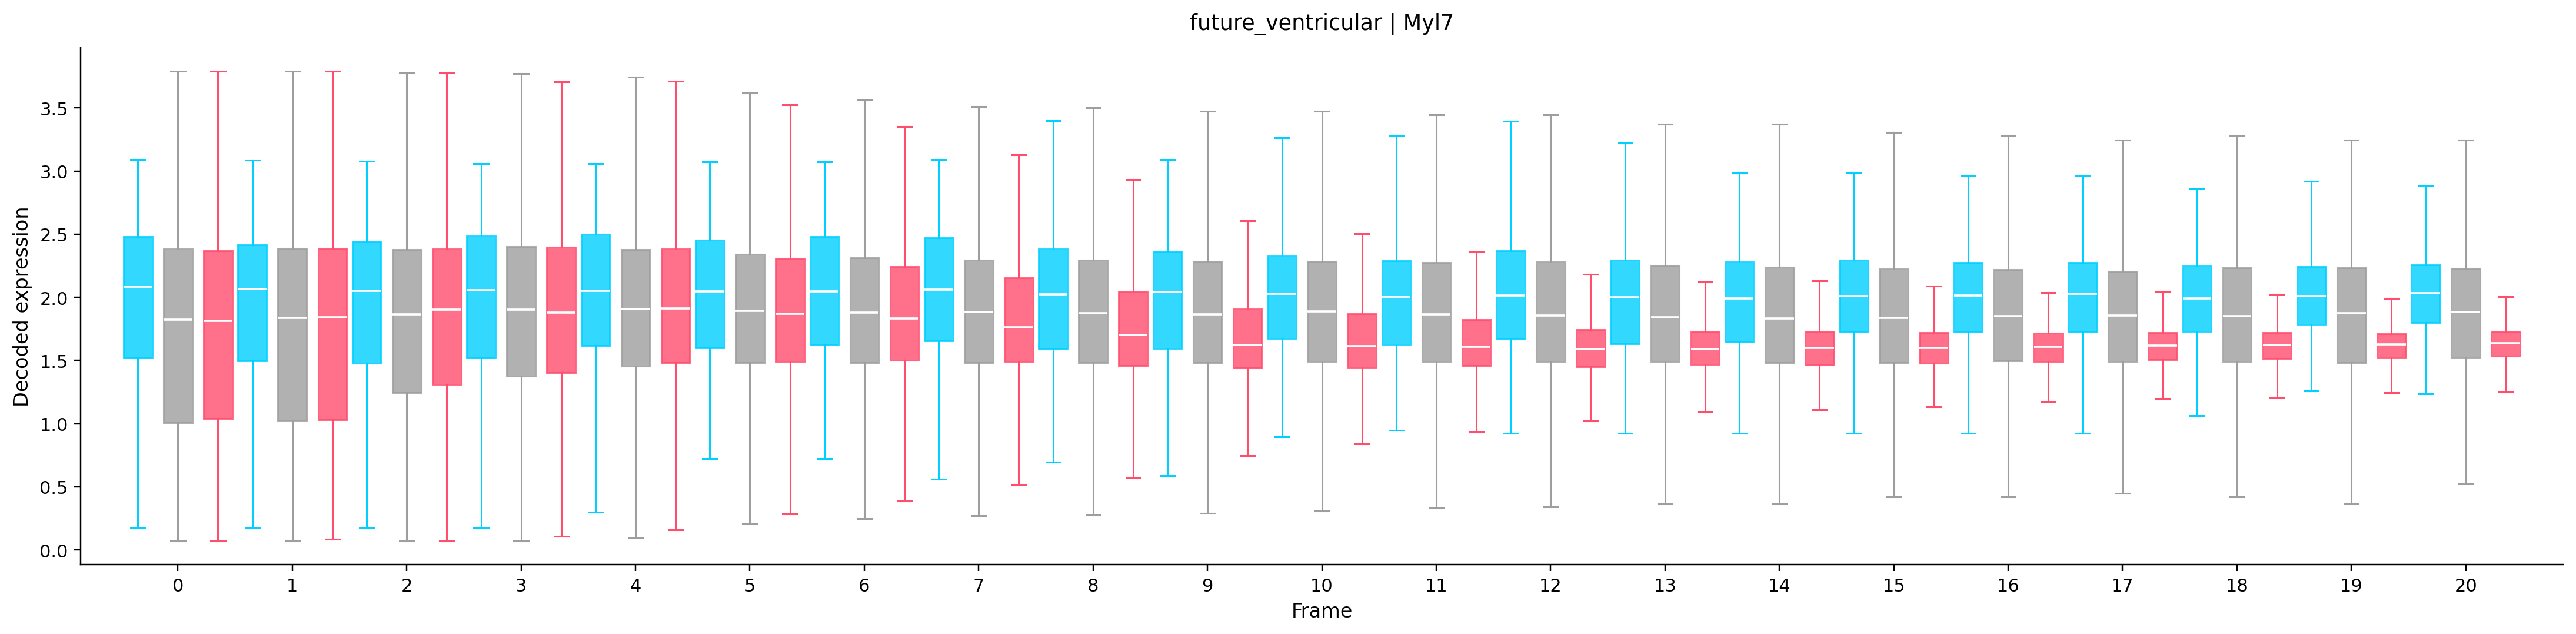

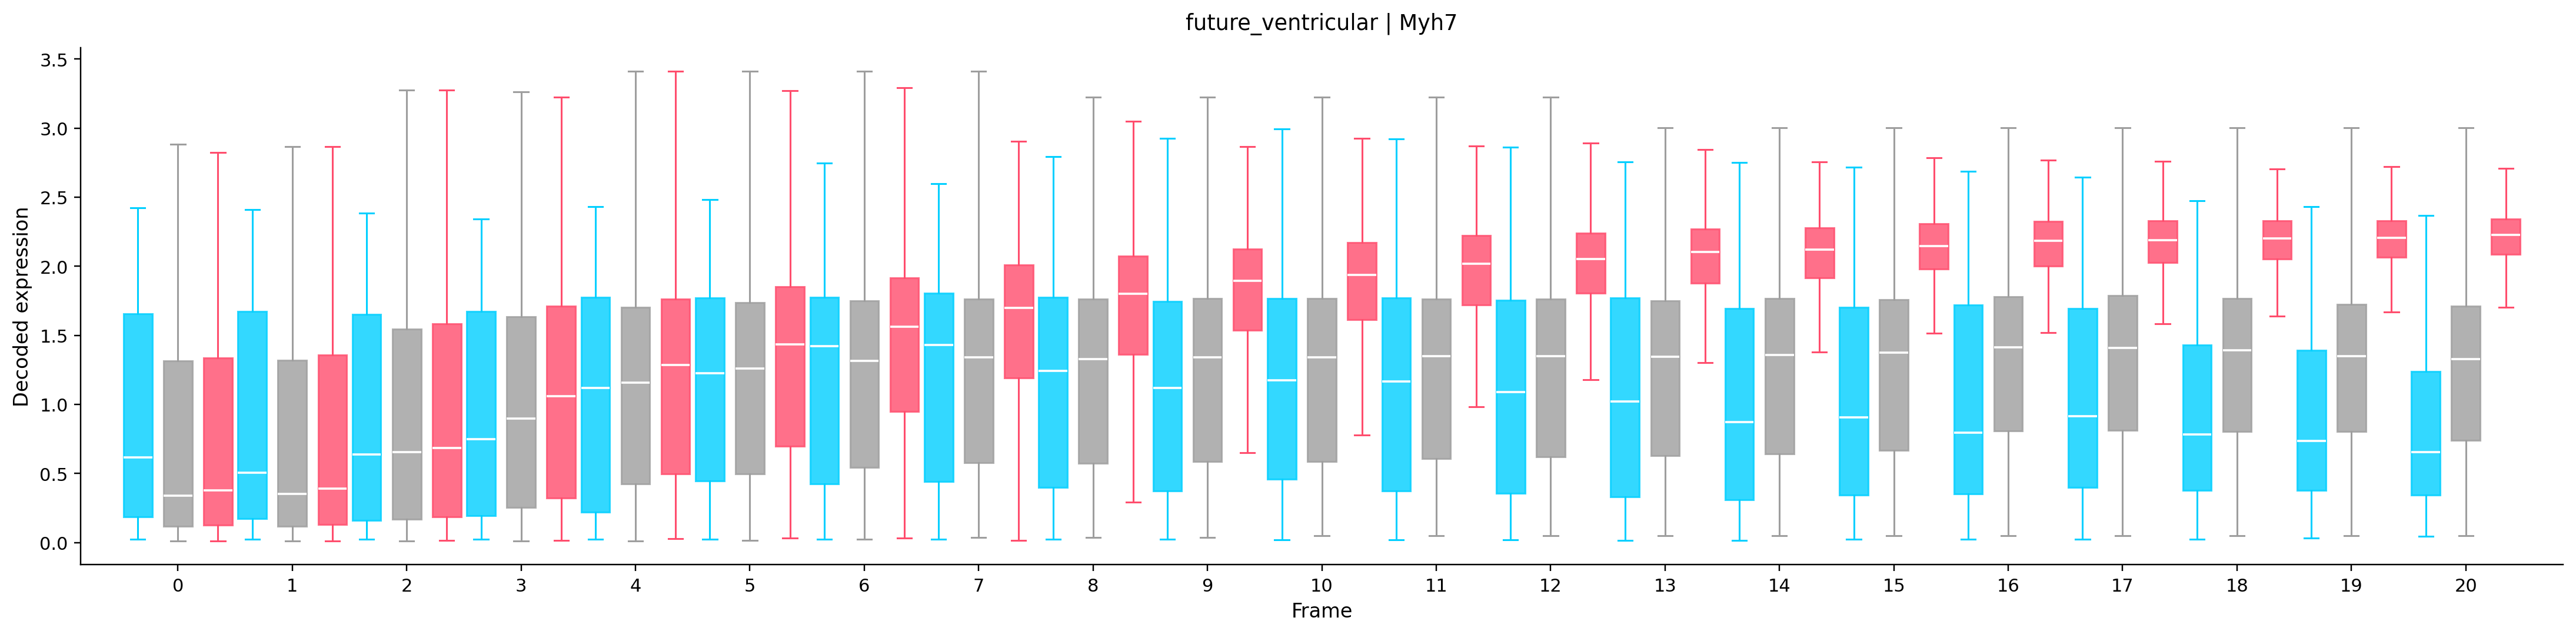

In [166]:
plot_marker_boxplots_by_cell_state_transition_with_ori(
    plot_df_vent,
    plot_df_ori=plot_df_ori_vent,
    source_group="future_ventricular",
    genes=("Myl7", "Myh7"),
    out_dir=str(session.start() / 'marker_boxplots_ventricular_with_ori'),
    frame_col="frame_num",
    expr_col="expr",
    cell_state_transition_col="seed_terminal_cell_state_transition",
    group0="ori",
    group1="atrial",
    group2="ventricular",
    ylabel="Decoded expression",
    showfliers=False,
)

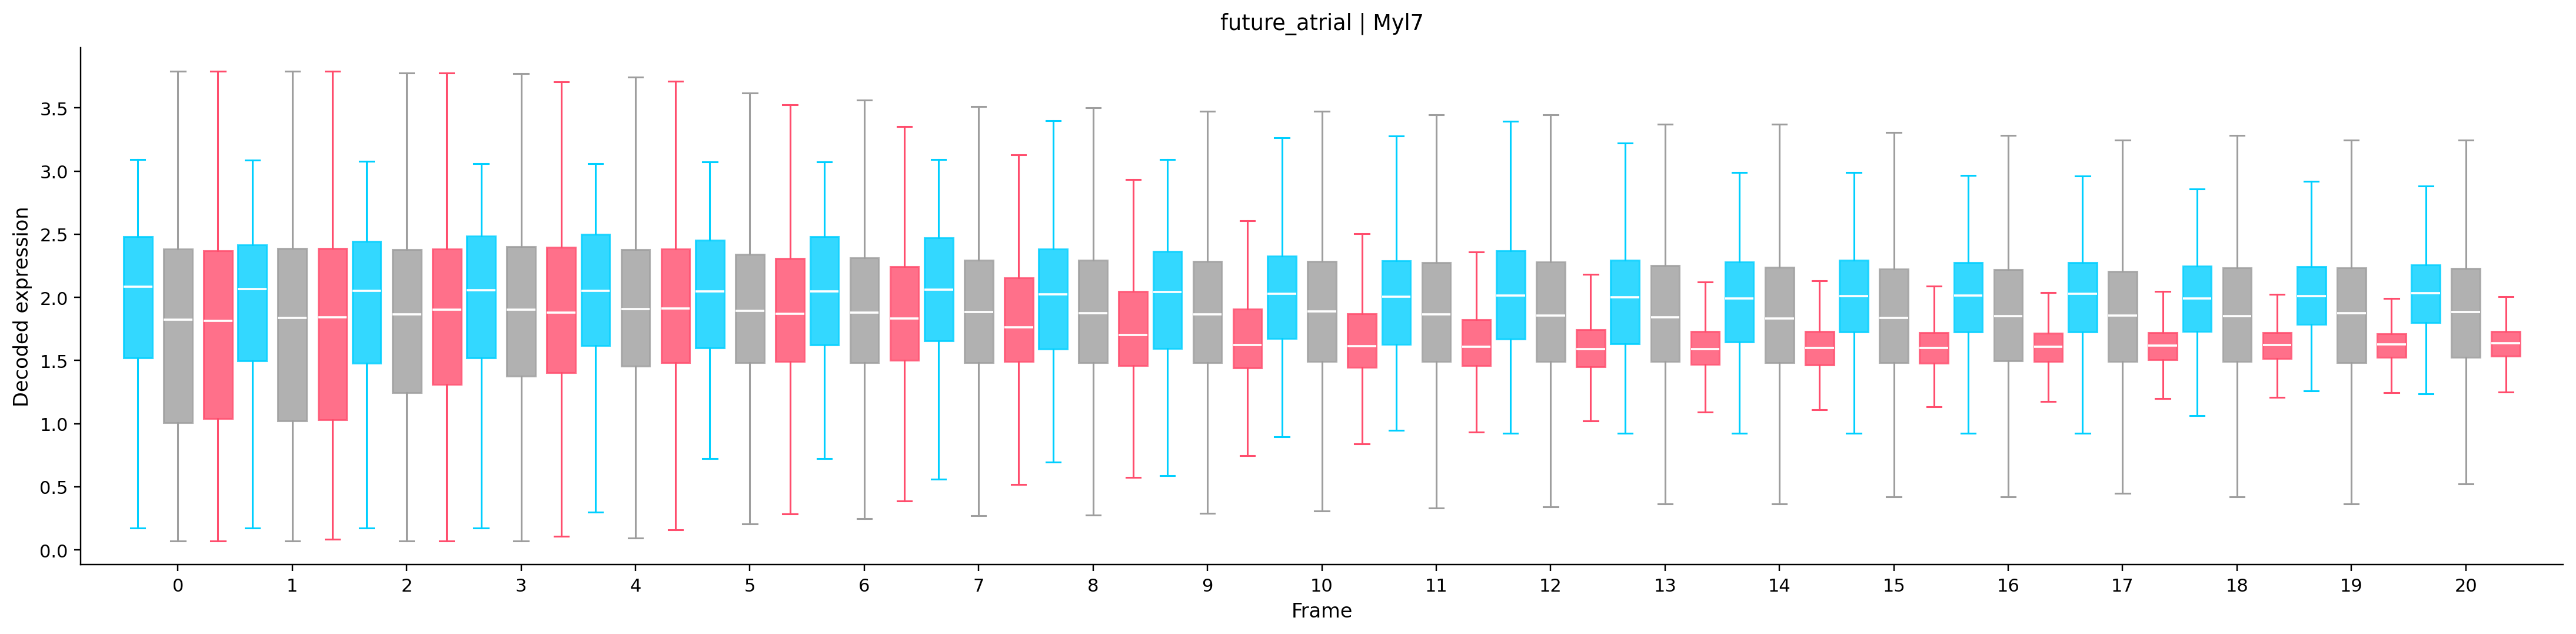

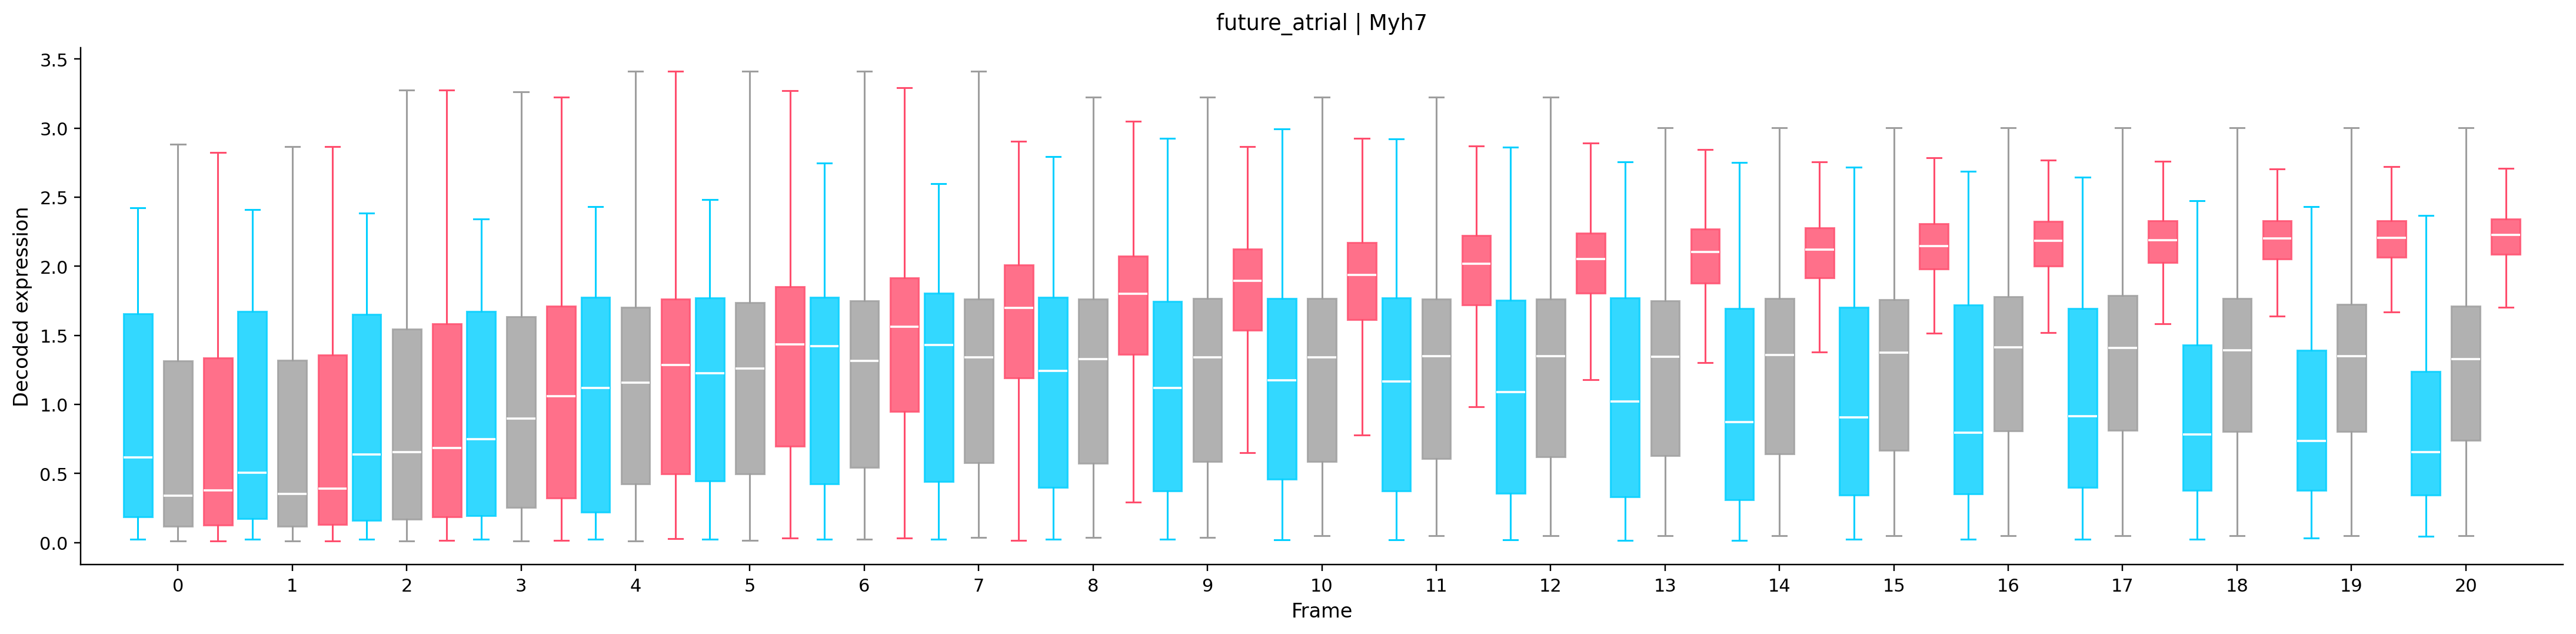

In [167]:
plot_marker_boxplots_by_cell_state_transition_with_ori(
    plot_df_vent,
    plot_df_ori=plot_df_ori_vent,
    source_group="future_atrial",
    genes=("Myl7", "Myh7"),
    out_dir=str(session.start() / 'marker_boxplots_atrial_with_ori'),
    frame_col="frame_num",
    expr_col="expr",
    cell_state_transition_col="seed_terminal_cell_state_transition",
    group0="ori",
    group1="atrial",
    group2="ventricular",
    ylabel="Decoded expression",
    showfliers=False,
)

In [186]:
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_marker_median_lines_by_cell_state_transition_with_ori(
    plot_df,
    *,
    source_group,
    genes=("Myl7", "Myh7"),
    plot_df_ori=None,
    out_dir=None,
    frame_col="frame_num",
    expr_col="expr",
    cell_state_transition_col="seed_terminal_cell_state_transition",
    group0="ori",
    group1="atrial",
    group2="ventricular",
    ylabel="Decoded expression",
    palette=None,
    figsize=(8.0, 5.0),
    dpi=220,
    marker_size=10,
    line_width=4.0,
):
    """
    Plot median curves only:
    - ori: gray
    - atrial: blue
    - ventricular: pink
    - Transparent background.
    - Show the left and bottom spines.
    """

    if palette is None:
        palette = {
            str(group0): "#9e9e9e",
            str(group1): "#00cfff",
            str(group2): "#ff4d6d",
        }

    genes_real = [g for g in genes if g in plot_df["gene"].unique()]
    if plot_df_ori is not None and len(plot_df_ori) > 0:
        genes_real = [g for g in genes_real if g in plot_df_ori["gene"].unique()]
    if len(genes_real) == 0:
        raise ValueError("plot_df / plot_df_ori contains no genes to plot")

    frames = sorted(plot_df[frame_col].dropna().astype(int).unique().tolist())
    if plot_df_ori is not None and len(plot_df_ori) > 0:
        frames_ori = sorted(plot_df_ori[frame_col].dropna().astype(int).unique().tolist())
        frames = sorted(set(frames) | set(frames_ori))

    if out_dir is not None:
        os.makedirs(out_dir, exist_ok=True)

    def _median_by_frame(df_sub, frames_):
        med = []
        for fr in frames_:
            x = df_sub.loc[df_sub[frame_col] == fr, expr_col].dropna().to_numpy()
            if len(x) == 0:
                med.append(np.nan)
            else:
                med.append(np.nanmedian(x))
        return np.asarray(med, dtype=float)

    for gene in genes_real:
        dfp = plot_df.loc[
            (plot_df["gene"] == str(gene)) &
            (plot_df[cell_state_transition_col].isin([str(group1), str(group2)])) &
            (plot_df[frame_col].isin(frames))
        ].copy()

        dfo = None
        if plot_df_ori is not None and len(plot_df_ori) > 0:
            dfo = plot_df_ori.loc[
                (plot_df_ori["gene"] == str(gene)) &
                (plot_df_ori[cell_state_transition_col] == str(group0)) &
                (plot_df_ori[frame_col].isin(frames))
            ].copy()

        if len(dfp) == 0 and (dfo is None or len(dfo) == 0):
            print(f"[skip] {source_group} | {gene}: no data")
            continue

        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        fig.patch.set_alpha(0.0)
        ax.set_facecolor("none")

        x = np.asarray(frames, dtype=float)

        # ori
        if dfo is not None and len(dfo) > 0:
            med0 = _median_by_frame(dfo, frames)
            ax.plot(
                x, med0,
                color=palette[str(group0)],
                lw=line_width,
                marker="o",
                ms=marker_size,
                label=str(group0),
            )

        # atrial
        df1 = dfp.loc[dfp[cell_state_transition_col] == str(group1)].copy()
        med1 = _median_by_frame(df1, frames)
        ax.plot(
            x, med1,
            color=palette[str(group1)],
            lw=line_width,
            marker="o",
            ms=marker_size,
            label=str(group1),
        )

        # ventricular
        df2 = dfp.loc[dfp[cell_state_transition_col] == str(group2)].copy()
        med2 = _median_by_frame(df2, frames)
        ax.plot(
            x, med2,
            color=palette[str(group2)],
            lw=line_width,
            marker="o",
            ms=marker_size,
            label=str(group2),
        )

        ax.set_xticks(frames)
        ax.set_xticklabels(frames)
        ax.set_xlabel("Frame", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f"{source_group} | {gene}", fontsize=12, pad=10)

        # Show the left and bottom spines.
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Adjust label colors for display on a dark background.
        ax.title.set_color("white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
        ax.tick_params(axis="x", colors="white")
        ax.tick_params(axis="y", colors="white")
        ax.spines["left"].set_color("white")
        ax.spines["bottom"].set_color("white")

        # leg = ax.legend(frameon=False, loc="upper right")
        # if leg is not None:
        #     plt.setp(leg.get_texts(), color="white")
        #     leg.get_title().set_color("white") if leg.get_title() else None

        plt.tight_layout()

        if out_dir is not None:
            save_path = os.path.join(
                out_dir,
                f"{source_group}_{gene}_median_line_with_ori.png".replace("/", "_").replace(" ", "_")
            )
            plt.savefig(save_path, bbox_inches="tight", transparent=True)

        plt.show()

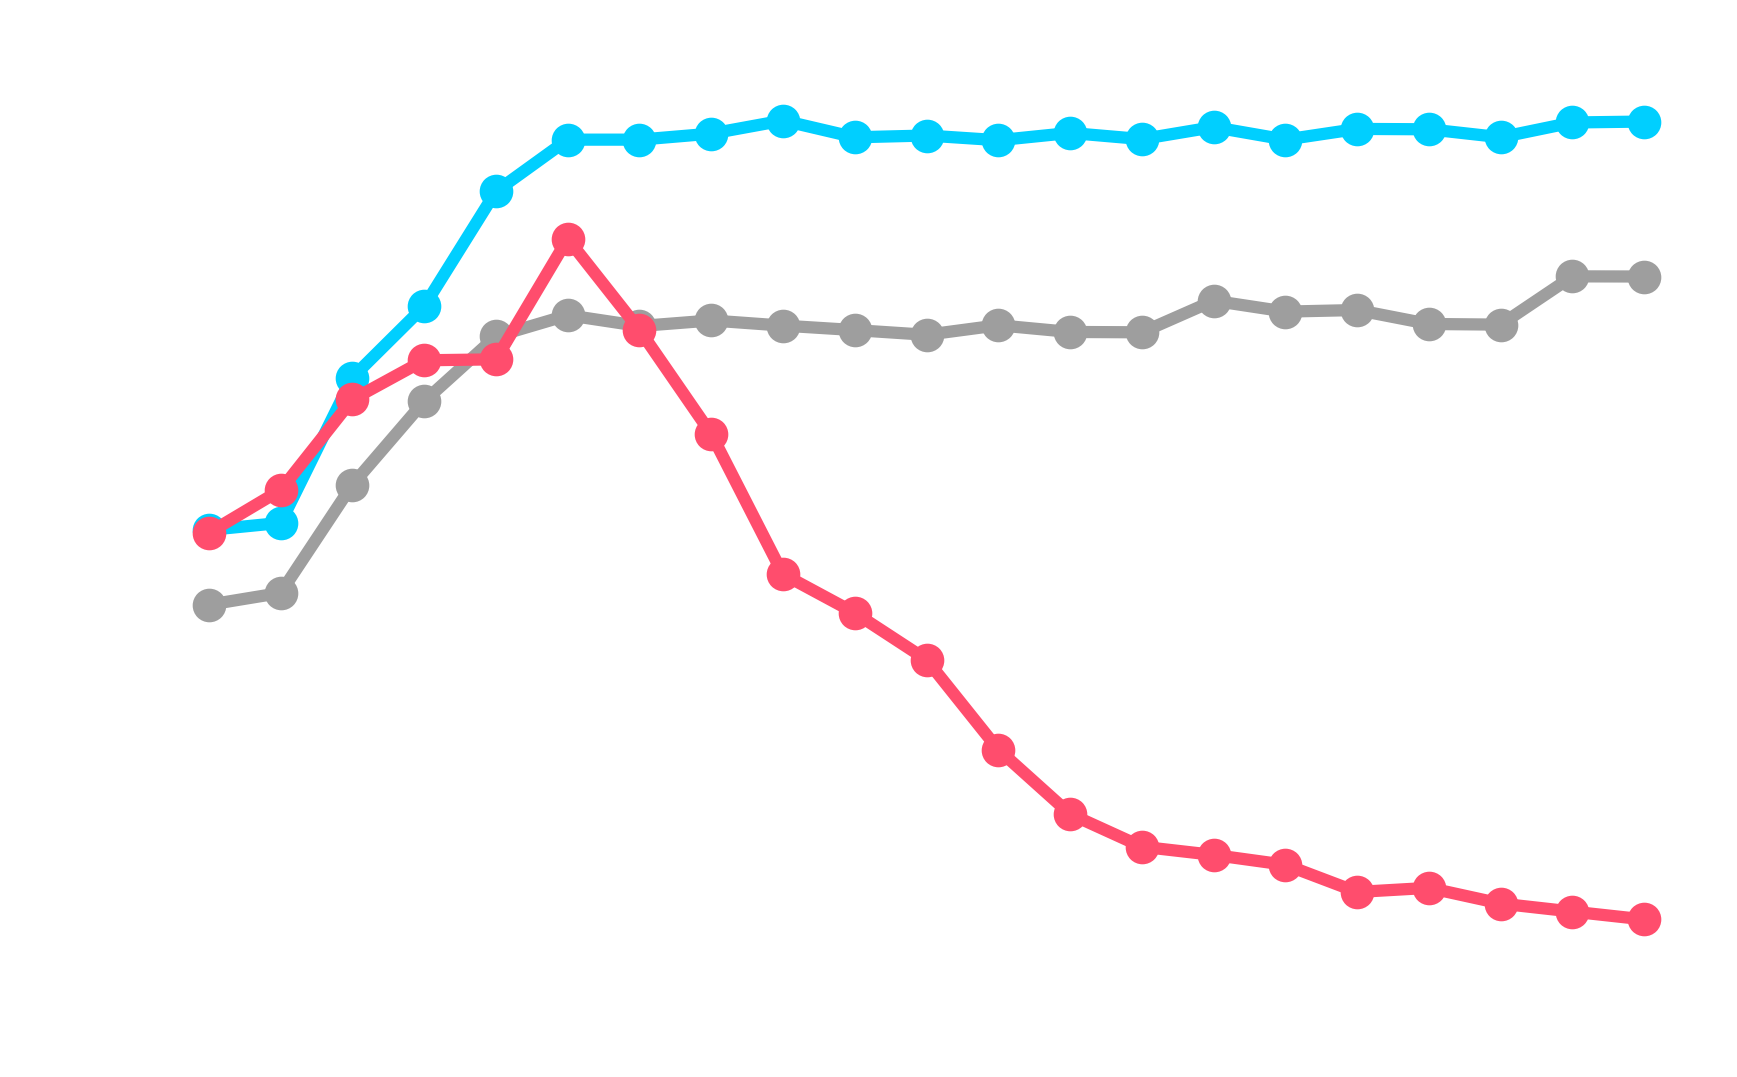

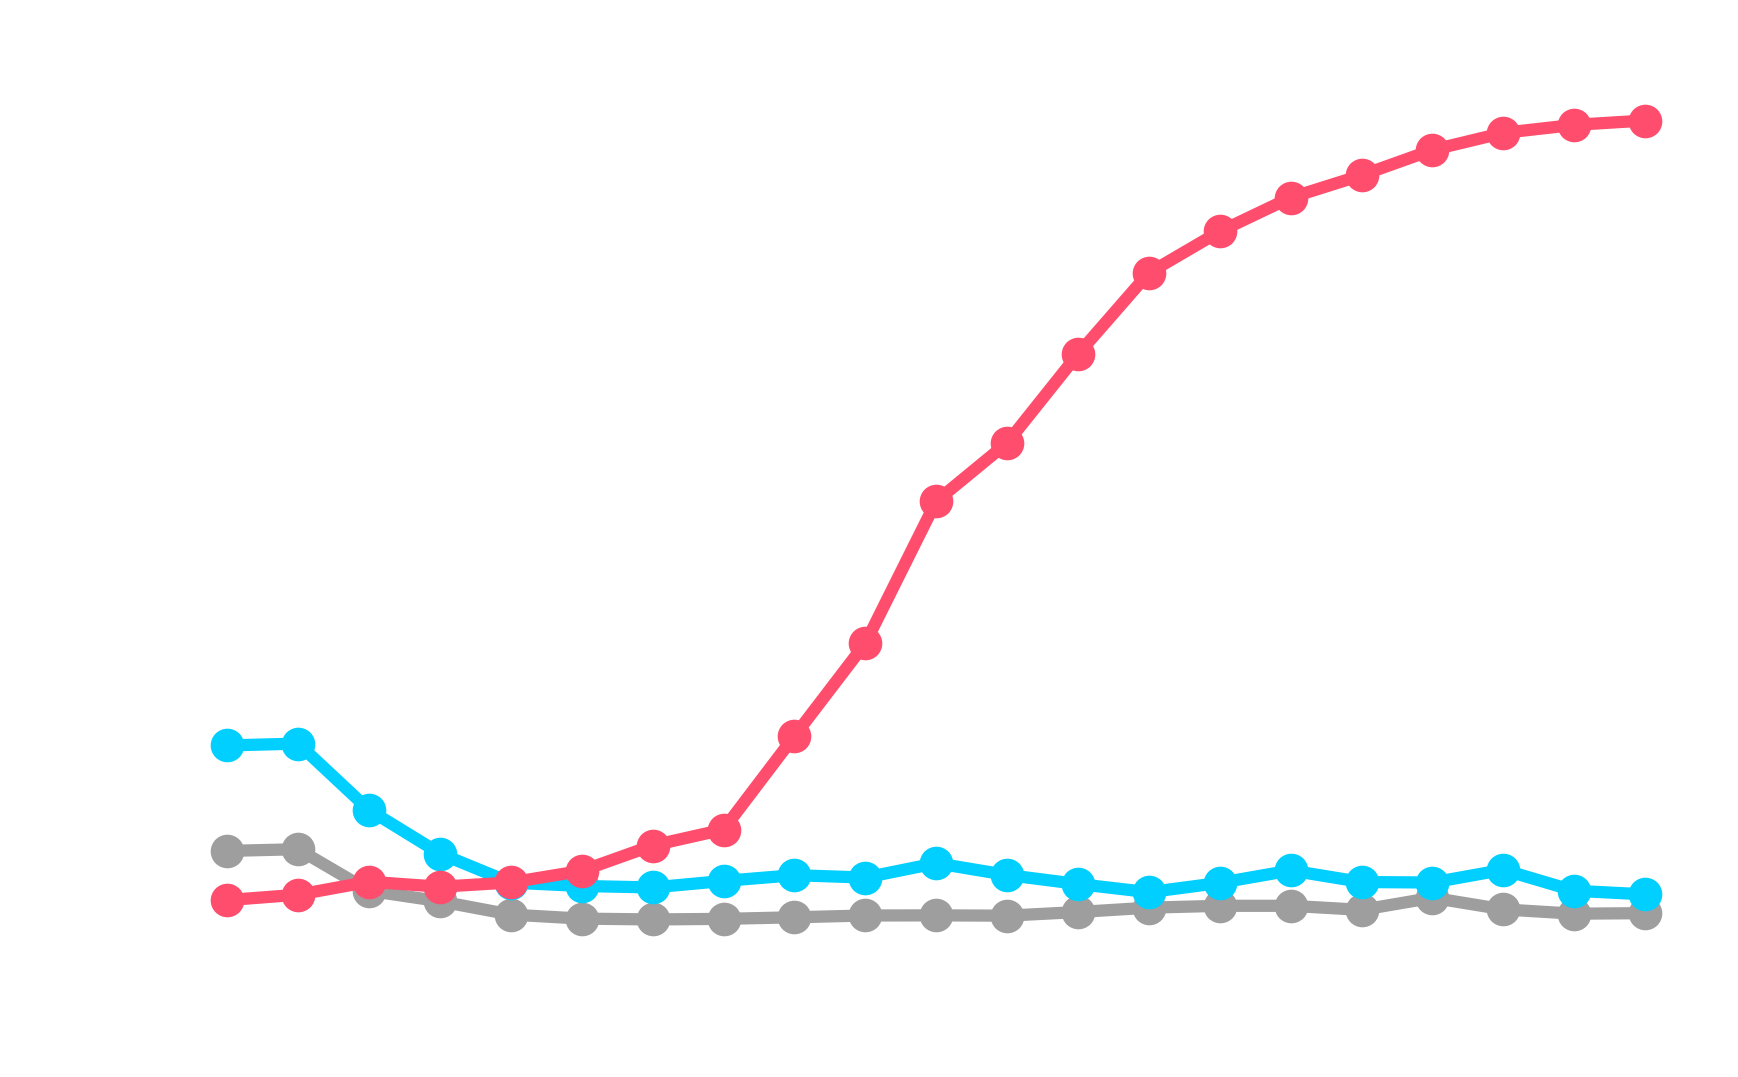

In [187]:
plot_marker_median_lines_by_cell_state_transition_with_ori(
    plot_df_atrial,
    plot_df_ori=plot_df_ori_atrial,
    source_group="future_atrial",
    genes=("Myl7", "Myh7"),
    out_dir=str(session.start() / 'marker_lines_atrial_with_ori'),
    frame_col="frame_num",
    expr_col="expr",
    cell_state_transition_col="seed_terminal_cell_state_transition",
    group0="ori",
    group1="atrial",
    group2="ventricular",
    ylabel="Decoded expression",
)

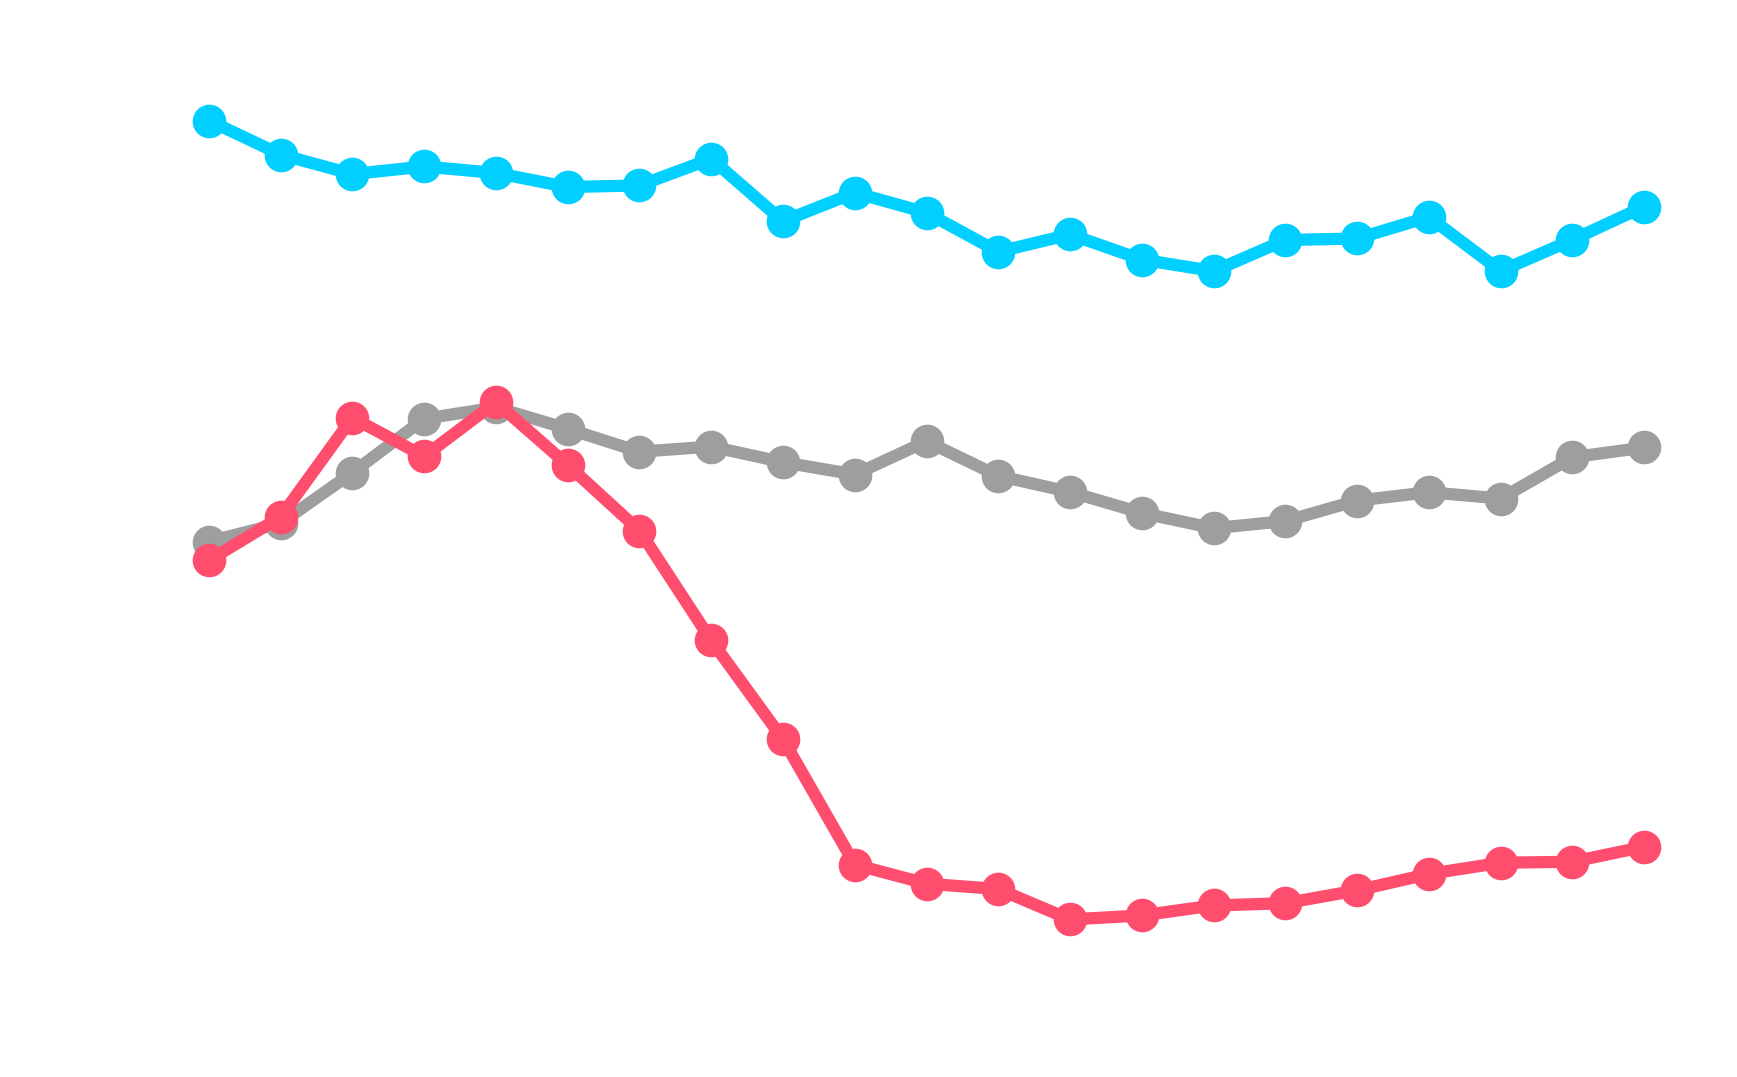

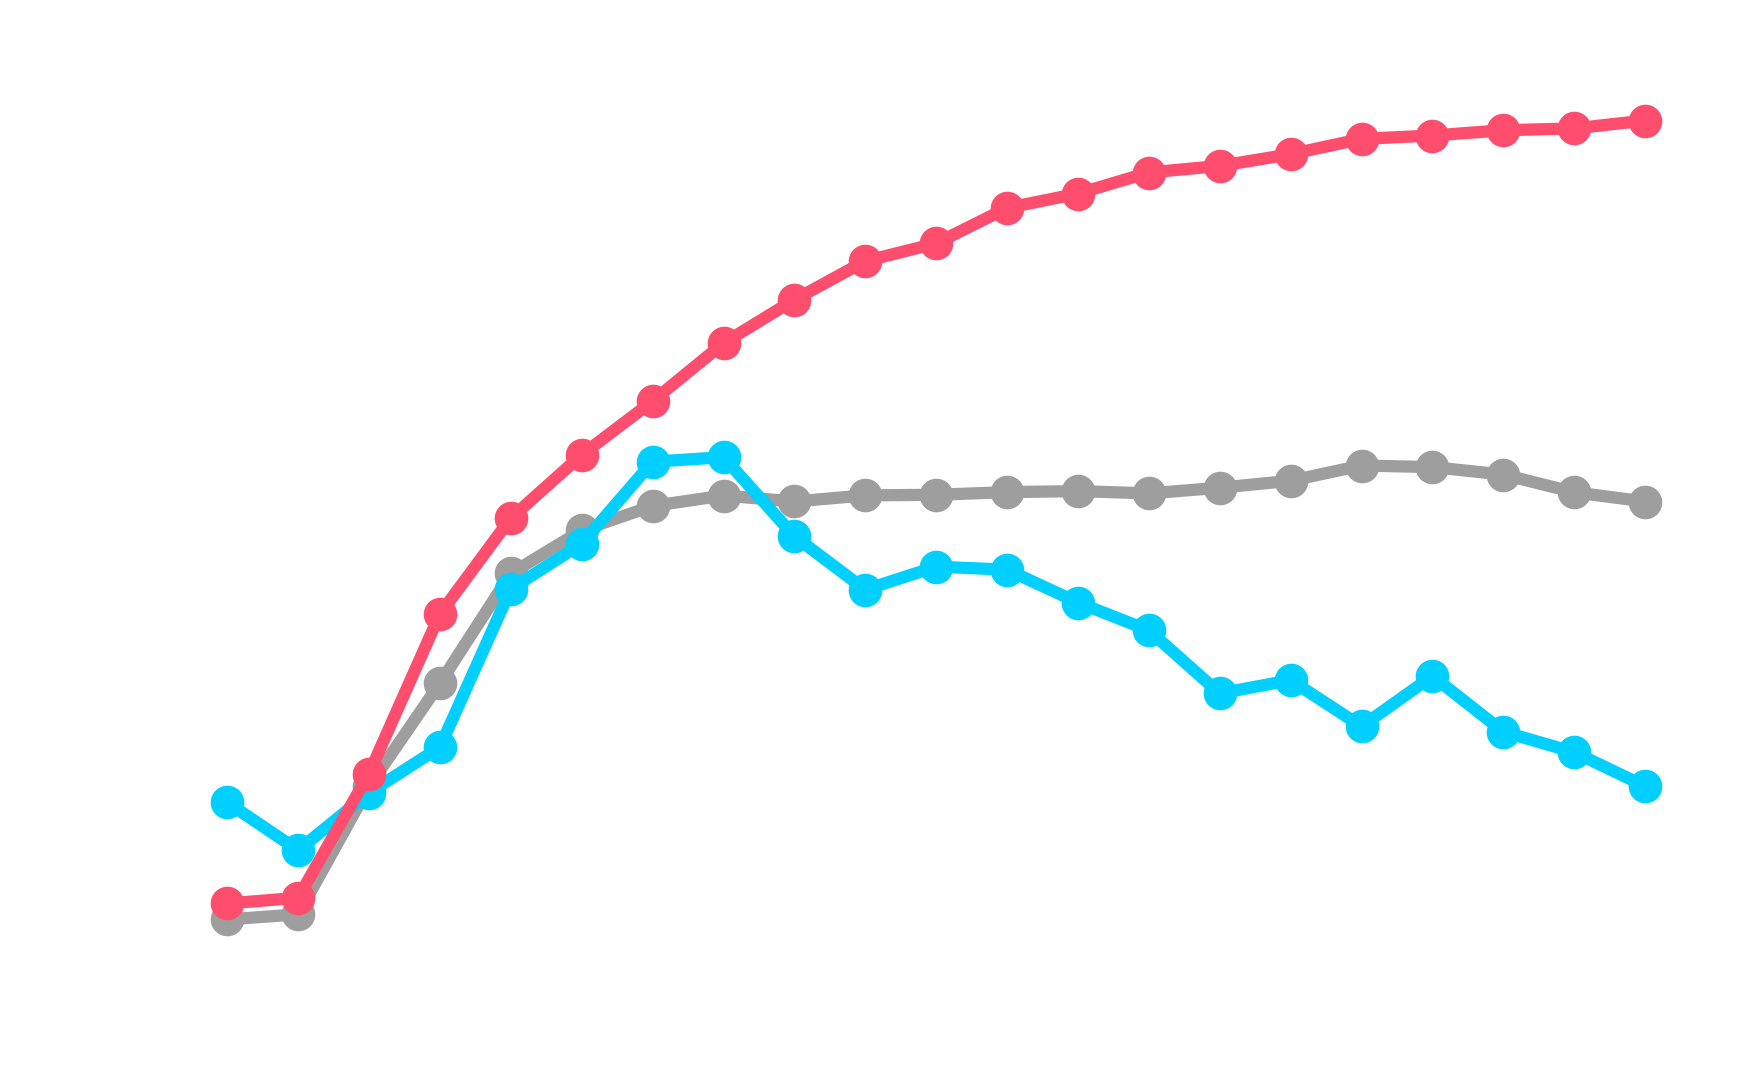

In [188]:
plot_marker_median_lines_by_cell_state_transition_with_ori(
    plot_df_vent,
    plot_df_ori=plot_df_ori_vent,
    source_group="future_ventricular",
    genes=("Myl7", "Myh7"),
    out_dir=str(session.start() / 'marker_lines_ventricular_with_ori'),
    frame_col="frame_num",
    expr_col="expr",
    cell_state_transition_col="seed_terminal_cell_state_transition",
    group0="ori",
    group1="atrial",
    group2="ventricular",
    ylabel="Decoded expression",
)